In [73]:
import sys, scipy 
import os
from io import StringIO
from collections import OrderedDict as odict
import numpy as np
import matplotlib
import yaml 
from scipy import integrate 
from scipy.integrate import quad
from scipy.integrate import dblquad
from scipy.misc import derivative 
import numpy as np
from scipy.integrate import tplquad
from scipy.integrate import romberg 
from scipy import special  
import vegas
import math
import numpy as np
import vegas
from scipy.interpolate import interp1d
import glob
import re
from matplotlib.patches import Ellipse, PathPatch, Rectangle
from matplotlib.path import Path
from IPython.display import set_matplotlib_formats  
from sashimi_si import *
import matplotlib.pyplot as plt  
matplotlib.rcParams['text.usetex'] = False 
import matplotlib.pyplot as plt  
import yaml

plt.rc('font', **{'family':'sans-serif','size':15})
plt.rc('text', usetex=False)
plt.rc('xtick', labelsize=15)
plt.rc('ytick', labelsize=15)
plt.rcParams['xtick.major.size']  = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.size']  = 2
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 5
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.size']  = 2
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['xtick.direction']   = 'in'
plt.rcParams['ytick.direction']   = 'in'
plt.rcParams['xtick.major.pad']   = 8
plt.rcParams['xtick.top']         = True
plt.rcParams['ytick.right']       = True


In [20]:
# Credit / citation:
# This code uses the sashimi package by 
# https://github.com/shinichiroando/sashimi-si 

# The mircolensing analysis code is written by Johanna Paine, 2025 

In [21]:
'''
These are global input parameters 
Host_Mass : Mass of the dark matter in the host galaxy in solar mass 
Sig  : (sigma0 / m_chi) in cm^2 g^-1,  the transfer momentum cross section  
W        : velocity scale in km s^-1, dark matter particle mass to dark matter mediate mass ratio 
'''

Sig= 10000
W =  300 


#Sig = 470.1786 
#W =4.384364
 
#Sig= 1000
#W = 1000
Host_Mass =  1.5e12 # per host hal 


In [22]:
# This runs sashimi 
# decrease DZ the plot have step feature to increase the grid resolution 

sh = subhalo_properties(sigma0_m=Sig,w=W) 
DZ= 0.03 # low res test 
ma200, z_acc, rsCDM_acc, rhosCDM_acc, rmaxCDM_acc, VmaxCDM_acc, rsSIDM_acc, rhosSIDM_acc, rcSIDM_acc, rmaxSIDM_acc, VmaxSIDM_acc, m_z0, rsCDM_z0, rhosCDM_z0, rmaxCDM_z0, VmaxCDM_z0, rsSIDM_z0, rhosSIDM_z0, rcSIDM_z0, rmaxSIDM_z0, VmaxSIDM_z0, ctCDM_z0, tt_ratio, weightCDM, weightSIDM, surviveCDM, surviveSIDM = sh.subhalo_properties_calc(1.e12*sh.Msun,redshift=0.,M0_at_redshift=True,dz=DZ,N_herm=50,zmax=5.,logmamin=-6,N_ma=1000)
   

Calculating subhalo properties: 100%|██████████| 63/63 [00:49<00:00,  1.27it/s]


In [23]:
condition = (weightSIDM > 0.) * (tt_ratio > 1.)
q = m_z0[condition] / sh.Msun
N, lnx_edges = np.histogram(np.log(q), weights=weightCDM[condition], bins=100)
lnx = (lnx_edges[1:] + lnx_edges[:-1]) / 2.
x2 = np.exp(lnx)
dlnx2 = lnx_edges[1:] - lnx_edges[:-1]
dNdlnx2 = N / dlnx2

In [24]:
def psi(m): 
    M_sun     = 1.988416e30       
    M_host_sol  = Host_Mass  
    M_host_kg  = M_host_sol * M_sun
    M_sol =  x2 
    dN_dlnM_sol = dNdlnx2
    M_kg          = M_sol  * M_sun ############# M_sol is mass in solar masss from sashimi M_sun is converion
    psi_mass_frac = (M_kg * dN_dlnM_sol) / M_host_kg 
    logM = np.log10(M_kg)
    logψ = np.log10(psi_mass_frac)
    psi_interp = interp1d(logM, logψ, kind='linear', fill_value='extrapolate')
    m = np.asarray(m)
    return (10**psi_interp(np.log10(m)))   / (m)   

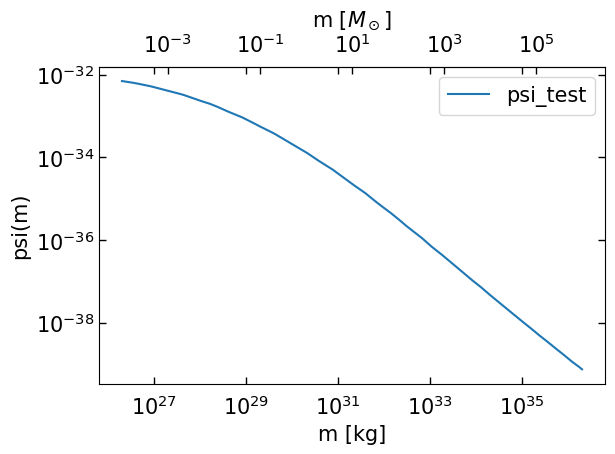

In [25]:
M_sun=1.988416e30
ms=np.logspace(np.log10(M_sun*1e-4),np.log10(M_sun*1e6),2000)

fig,ax=plt.subplots()
ax.loglog(ms,psi(ms),label="psi_test")
ax.set_xlabel("m [kg]"); ax.set_ylabel("psi(m)")
ax.legend()

secax=ax.secondary_xaxis("top",functions=(lambda x:x/M_sun,lambda x:x*M_sun))
secax.set_xlabel("m [$M_\\odot$]")

plt.tight_layout(); plt.show()

In [26]:
# Density profile options for compute_Q:
# Each function returns the host DM density ρ(r) evaluated along a line of sight.
#
# Common signature:
#   rho(x, L, R0, Rc, rho0, b_rad, l_rad)
# where:
#   x      : dimensionless LOS parameter, 0 to 1, how far along the line of sight is the lens 
#   L      : total LOS length / max distance [same length units as R0, Rc]
#   R0     : Sun to glatic center  distance [length]
#   Rc     : core radius (only used by cored/isothermal) [length]
#   rho0   : reference density / normalization (meaning depends on profile)
#   b_rad  : Galactic latitude in radians
#   l_rad  : Galactic longitude in radians
#
# Use in compute_Q by passing one of these as the density callback, e.g.
#   Q = compute_Q(..., rho_fn=nfw_density_sashimi, ...)
#
# Implementations:
# - nfw_density_sashimi: NFW with fixed (rs, rhos) taken from SASHIMI host fit (units: meters, kg/m^3).
# - rho_iso: cored isothermal profile (uses Rc, rho0).
# - rho_nfw: simple NFW test profile using (R0, rho0) + assumed concentration c_nfw=12.
# - rho_har_nwf: alternate NFW, using c_nfw=16 

In [27]:
# all rho funcations 

def nfw_density_sashimi(x, L, R0, Rc, rho0, b_rad, l_rad):
    # Use correct NFW host parameters
    rs_m = 7.24734e20        # scale radius in meters (23.5 kpc)
    rhos_kg_m3 = 2.993e-22   # characteristic density in kg/m^3

    # Distance squared from GC
    R2 = L**2 * x**2 - 2 * L * x * R0 * np.cos(b_rad) * np.cos(l_rad) + R0**2
    r = np.sqrt(R2)
    u = r / rs_m
    return rhos_kg_m3 / (u * (1 + u)**2)

def rho_iso(x, L, R0, Rc, rho0, b_rad, l_rad):
    R2 = L**2 * x**2 - 2 * L * x * R0 * np.cos(b_rad) * np.cos(l_rad) + R0**2
    return rho0 * (Rc**2 + R0**2) / (Rc**2 + R2) 

def rho_nfw(x, L, R0, RC,rho0, b_rad, l_rad):
     # a test case 
    c_nfw = 12.0
    r_s   = R0 / c_nfw
    rho_s = rho0 * c_nfw * (1 + c_nfw)**2

    R2 = L**2 * x**2 - 2 * L * x * R0 * np.cos(b_rad) * np.cos(l_rad) + R0**2
    u  = np.sqrt(R2) / r_s
    return rho_s / (u * (1 + u)**2)


def rho_har_nwf(x, L, R0, Rc, rho0, b_rad, l_rad):
    c_nfw = 16.0
    # winch paper 
    r_s   = R0 / c_nfw
    rho_s = rho0 * c_nfw * (1 + c_nfw)**2
    R2 = L**2 * x**2 - 2 * L * x * R0 * np.cos(b_rad) * np.cos(l_rad) + R0**2
    u  = np.sqrt(R2) / r_s
    return rho_s / (u * (1 + u)**2) 

In [28]:
# all psi funcations 
# This are options for psi the mass funcation to test a delta function,
# the delta funcation will match all monochromatic mass function contraints 
#  a result from a another sashimi paper, and a powerlaw, 
# psi generally will be the mass function from the sashimi input in the start of this notebook, which is what you want to 
# use for self interacting dark matter predictions 
def psi_delta_gauss(m):
    M0 = 1.0 * 1.988416e30     # 1 M_sun in kg
    sigma = 1e-3 * M0          # 0.1% width
    f = 1.0
    norm = 1/(sigma * np.sqrt(2*np.pi))
    return f * norm * np.exp(-0.5*((m - M0)/sigma)**2)

def psi_BH(m):
    M_sun = 1.988416e30 
    return (1/m)*  (1.2*10**(-11))* (m/ ((M_sun*(10**10))))**(-1.89) 

def psi_pl2(m,
            α=1.8,
            m_min=1e-2 * 1.9884e30,
            m_max=10   * 1.9884e30):
    if α != 1.0:
        A = (1 - α) / (m_max**(1 - α) - m_min**(1 - α))
    else:
        A = 1.0 / math.log(m_max / m_min)
    return A * m**(-α)



In [29]:
# all eff funcations 
# Effecincy function for different surverys and different forcast from other papers 
#  the from nastasha paper is the best for LSST 

def eff_eros(t):
    days = t / 86400
    μ, σ = 2.0, 1.0
    return np.exp(-(np.log10(days)-μ)**2)/(2*σ**2) 

def eff_LSST(t):
    # from nastasha paper 
     days = t/86400
     t0 = 22.33
     tr = 1.05
     return 1 / (1+((days/t0)**(-1/tr))   )   
 
def eff_Djuna(t_E_seconds):
    # Convert seconds to days
    t_E_days = t_E_seconds / 86400.0
    # Hard‑coded BDT‑fit parameters
    A, k, lam, c = 0.22, 0.19, 2.1e-3, -5.4e-2
    return A * (t_E_days**k) * np.exp(-lam * t_E_days) + c 

def eff_eros(t):
    days = t/86400
    μ, σ = 2.0, 1.0
    return np.exp(-(np.log10(days)-μ)**2)/(2*σ**2)

def eff_1(t):
    # Example: constant efficiency, adapt as needed
    return 1.0

In [30]:
def RE4_and_expQ(x, t, m, L, uT, G, c, v_c):
    RE2 = 4 * G * m * L * x * (1 - x) / c**2
    Q   = 4 * RE2 * uT**2 / (t**2 * v_c**2)
    return RE2**2, np.exp(-Q)

def prefactor_t(t, L, uT, G, c, v_c):
    return 32 * L * uT / (t**4 * v_c**2)

def compute_Q(
    t_min, t_max, x_min, x_max, m_min, m_max,
    E_exp,  
    psi_func,
    rho_func, halo_params,
    RE4_and_expQ_func, lens_params,  
    eff_func,
    prefactor_t_func,
   
):
    def integrand(X):
        t, x, m = X
        #VV = v_func(x,**halo_params)
        re4, eq = RE4_and_expQ_func(x, t, m, **lens_params)
        eff = eff_func(t)
        pref = prefactor_t_func(t, **lens_params) 
        psi_val = psi_func(m)
        rho_val = rho_func(x, **halo_params)
        return eff * pref * (psi_val / m) * rho_val * re4 * eq

    integ = vegas.Integrator([[t_min, t_max], [x_min, x_max], [m_min, m_max]])
    integ(integrand, nitn=5, neval=500)
    res = integ(integrand, nitn=15, neval=1000)
    Γ1, Q1 = res.mean, res.Q
    N1= Γ1 * E_exp * 3.154e7  
    Q_cutoff1 = 0.05
    
    if Q1 < Q_cutoff1:
        #print(f"Q={Q1:.3f} is less than Q1_cutoff={Q_cutoff1:.2f}, re-running with more samples...")
        integ(integrand, nitn=5, neval=5000)
        res = integ(integrand, nitn=15, neval=1e4)
        Γ1, Q1 = res.mean, res.Q
        N1 = Γ1 * E_exp * 3.154e7  
    
    '''

    if Q1 < Q_cutoff1:
            #print(f"Q={Q1:.3f} is still less than cutoff={Q_cutoff1:.2f} after 1e6 evals ")
            # Optionally, set values to None or np.nan to indicate a failure
            Γ1, Q1, N1 = np.nan, Q1, np.nan
        
        # add condition for print out of still bad 
    ''' 
    return Γ1, Q1, N1 

In [31]:
# These parameters are for EROS looing at the LMC and reproduce the results 
# in Djuna's Microlensing paper 

Rc    = 1.543e20  # 5 kpc 
R0    = 2.6231e20 # 8.2 kpc 
L_lmc = 1.543e21  # 50 kpc to LMC
uT    = 1
vv_c   = 220000
G     = 6.6743e-11
c     = 299792458 # m/s 
rho0_AG  = 0.0079 * 1.989416e30 / (3.086e16)**3
b_LMC = np.deg2rad(-33)
l_LMC = np.deg2rad(280)

halo_paramsLMC = dict(L=L_lmc, R0=R0,Rc=Rc,rho0=rho0_AG, b_rad=b_LMC, l_rad=l_LMC)
lens_paramsLMC = dict(L=L_lmc, uT=uT, G=G, c=c,v_c= 220e3) 
# Integration bounds

t_min, t_max = 0.0001,    3.15e8
t_5y = 3.15e8/2 
x_min, x_max = 0.0,    1.0
m_min, m_max = 1e30, 1e32
E_eros = 3.77e7  # years
Γ, Q, N = compute_Q(
    t_min, t_5y, x_min, x_max, m_min, m_max,
    E_exp=E_eros,
    psi_func=psi_delta_gauss,
    rho_func=rho_iso, halo_params=halo_paramsLMC,
    RE4_and_expQ_func=RE4_and_expQ, lens_params=lens_paramsLMC,
    eff_func=eff_eros,
    prefactor_t_func=prefactor_t,
   
)
# takes 0.2 seconds 
print(f"[ψ≈δ at 1 M☉] Γ={Γ:.3e},Q={Q:.3e} s⁻¹ → N_exp≈{N:.3f}")
# this is the key test, should be ~ 27 to test a delta mass funcation 
# this will return nan 1/10 times do the statisical nature of vegas, just run again. Nan happen when the integral doesnt converer on Q thershold 


[ψ≈δ at 1 M☉] Γ=2.341e-14,Q=1.139e-01 s⁻¹ → N_exp≈27.834


In [32]:
# this parameters are for LSST looking towards the galatic bulge 
# Most SIDM psi will have no events towards the LMC     
# number of event in one year of observatoion 

M_sun = 1.988416e30     
b_B = np.deg2rad(-4)
l_B = np.deg2rad(1)
L_B = 2.6231e20

halo_paramsB = dict(L=L_B, R0=R0,Rc=Rc,rho0=2.993e-22 , b_rad=b_B, l_rad=l_B)
lens_paramsB = dict(L=L_B, uT=uT, G=G, c=c,v_c= vv_c) 

bΓ, bQ, bN = compute_Q(
        t_min, t_5y, x_min, x_max, m_min=M_sun*1e-4,  m_max=M_sun * 1e6,      
        E_exp=4e9,
        psi_func=psi,
        rho_func=nfw_density_sashimi, halo_params=halo_paramsB,
        RE4_and_expQ_func=RE4_and_expQ, lens_params=lens_paramsB,
        eff_func=eff_LSST,
        prefactor_t_func=prefactor_t,
    )

print(f"[ψ≈δ at 1 M☉] Γ={bΓ:.3e},Q={bQ:.3e} s⁻¹ → N_exp≈{bN:.3f}")

# this runs LSST parameters and usees our test mass function 
# should be ~0.044 events for Sig= 470.1786 W =4.384364


[ψ≈δ at 1 M☉] Γ=6.722e-17,Q=3.606e-01 s⁻¹ → N_exp≈8.481


In [33]:
# lets now compute the eq  mass and the dark matter fraction 
def f_dm_from_psi(psi_func, m_min, m_max, *, warmup=5, nitn=10, neval=10_000):
    integ = vegas.Integrator([[m_min, m_max]])
    def g(x): return psi_func(x[0])
    integ(g, nitn=warmup, neval=neval)
    res = integ(g, nitn=nitn, neval=neval)
    return res.mean, getattr(res, "Q", np.nan)

def meq_from_psi(psi_func, m_min, m_max, *, warmup=5, nitn=12, neval=20_000):
    integ = vegas.Integrator([[m_min, m_max]])
    def g0(x): M = x[0]; return psi_func(M)               # f = ∫ ψ dM
    def g1(x): M = x[0]; return (M**-0.5) * psi_func(M)   # J = ∫ M^-1/2 ψ dM
    integ(g0, nitn=warmup, neval=neval)
    f_res = integ(g0, nitn=nitn, neval=neval)
    J_res = integ(g1, nitn=nitn, neval=neval)
    f, J = f_res.mean, J_res.mean
    if not (np.isfinite(f) and f > 0 and np.isfinite(J) and J > 0):
        Q = min(getattr(f_res, "Q", np.nan), getattr(J_res, "Q", np.nan))
        return np.nan, Q, f
    Q = min(getattr(f_res, "Q", np.nan), getattr(J_res, "Q", np.nan))
    return (f / J)**2, Q, f

In [34]:
m_min,m_max=1e-4,1e6
# takes about 2 mins 
f,Qf=f_dm_from_psi(psi,m_min,m_max)
meq,Qm,f2=meq_from_psi(psi,m_min,m_max)

print("f_dm =",f," Q =",Qf)
print("m_eq =",meq," Q =",Qm," (f_dm check =",f2,")")

# f_dm and m_eq are the dark matter fraction the equilant delta function lens mass in to to compare to other constaint plots 

f_dm = 2.4618925816053194e-65  Q = 0.31654195966818743
m_eq = 706024.445412378  Q = 0.013550915635917447  (f_dm check = 2.46189852286555e-65 )


In [35]:
x=np.log10(meq)
print(f"m_eq = {meq:.3e} = 10^{x:.3f}")

m_eq = 7.060e+05 = 10^5.849


In [36]:

def f_dm_from_psi(psi_func, m_min, m_max, *, warmup=8, nitn=20, neval=200_000, seed=None, eps=1e-12, verbose=True):
    assert m_max>m_min
    if seed is not None: np.random.seed(seed)
    a=max(m_min+0.0, eps if m_min<=0 else m_min+0.0)   # avoid 0/neg edge
    b=m_max
    integ=vegas.Integrator([[a,b]])
    def g(x):
        M=x[0]
        v=psi_func(M)
        return 0.0 if (not np.isfinite(v)) else v      # kill NaN/inf samples
    integ(g, nitn=warmup, neval=neval)                 # adapt
    res=integ(g, nitn=nitn, neval=neval)               # final
    f=float(res.mean); s=float(getattr(res,"sdev",np.nan)); Q=getattr(res,"Q",np.nan)
    if verbose: print(f"fdm = {f:.6e}  ± {s:.2e}  (rel {abs(s/f) if f else np.inf:.2e})  Q={Q:.3f}  [{a:.3e},{b:.3e}]")
    return f, Q

In [37]:
M_sun=1.988416e30
m_min=M_sun*1e-4
m_max=M_sun*1e6
#Sig= 1000
# W= 1000 
fdm,Q=f_dm_from_psi(psi,m_min,m_max,seed=0,warmup=8,nitn=20,neval=200_000,verbose=True)
print("fdm,Q =",fdm,Q)

fdm = 1.165943e-02  ± 1.93e-09  (rel 1.65e-07)  Q=0.907  [1.988e+26,1.988e+36]
fdm,Q = 0.011659426053019726 0.9068562919385226


In [38]:
M_sun=1.988416e30
m_min=M_sun*1e-4
m_max=M_sun*1e10

fdm,Q=f_dm_from_psi(psi,m_min,m_max,seed=0,warmup=8,nitn=20,neval=200_000,verbose=True)
print("fdm,Q =",fdm,Q)

fdm = 4.319557e-02  ± 1.64e-08  (rel 3.80e-07)  Q=0.864  [1.988e+26,1.988e+40]
fdm,Q = 0.04319556795782216 0.8637786189998845


In [2]:
import re, glob, os, numpy as np

def load_mf(folder):
    out = {}
    for p in sorted(glob.glob(os.path.join(folder, "sigma*_W*.txt"))):
        s, w = re.search(r"sigma([\d.eE+-]+)_W([\d.eE+-]+)", p).groups()
        x2, dN = np.genfromtxt(p, comments="#", unpack=True)
        out[(float(s), float(w))] = (x2, dN)
    return out

In [6]:
mfs = load_mf(os.path.expanduser("~/Desktop/mass_functions_copy"))
print(mfs.keys())
x2, dNdlnx2 = mfs[(0.1, 1.668101)]

dict_keys([(0.1082387, 0.32431), (0.1083026, 0.3347834), (0.1260251, 0.4423211), (0.1503167, 0.497198), (0.1567651, 0.4811923), (0.1704521, 0.3817654), (0.173643, 0.294617), (0.1811549, 0.3911643), (0.1860016, 0.4622515), (0.1970405, 0.3519826), (0.1, 0.4641589), (0.1, 1.0), (0.1, 1.668101), (0.1, 1000.0), (0.1, 21.54435), (0.1, 278.2559), (0.1, 5.994843), (0.1, 77.42637), (0.2088868, 0.3603152), (0.2105321, 0.392163), (0.2382164, 0.4506068), (0.2632187, 0.2904487), (0.2679113, 0.3556203), (0.2755667, 0.4306771), (0.2830091, 0.3722037), (0.2, 0.2), (0.2, 0.5152603), (0.2, 1.327466), (0.2, 1000.0), (0.2, 150.663), (0.2, 22.69935), (0.2, 3.419952), (0.2, 388.1533), (0.2, 58.48035), (0.2, 8.810827), (0.3047995, 0.2946896), (0.3118551, 0.2867222), (0.3230841, 0.3459551), (0.3267663, 0.4280215), (0.3436174, 0.2754752), (0.35268381484002115, 0.2721885846254622), (0.3593814, 0.129155), (0.3593814, 0.4641589), (0.3593814, 1.668101), (0.3593814, 1000.0), (0.3593814, 21.54435), (0.3593814, 278.2

In [12]:
import os, re, glob, csv
import numpy as np
import vegas
from scipy.interpolate import interp1d

M_sun = 1.988416e30  # kg

import os, re, glob, numpy as np

def load_mf(folder):
    out = {}
    for p in sorted(glob.glob(os.path.join(folder, "sigma*_W*.txt"))):
        m = re.search(r"sigma([\d.eE+-]+)_W([\d.eE+-]+)_l([\d.eE+-]+)_h([\d.eE+-]+)\.txt$",
                      os.path.basename(p))
        if not m:
            continue
        s, w, lo, hi = map(float, m.groups())
        x2, dN = np.genfromtxt(p, comments="#", unpack=True)
        out[(s, w, lo, hi)] = (x2, dN)
    return out 

# ---- build psi(m[kg]) closure for ONE mass function (mirrors notebook cell 5) ----
def make_psi(x2_Msun, dNdlnx2, Host_Mass_Msun):
    M_kg  = x2_Msun * M_sun
    psi_mass_frac = (M_kg * dNdlnx2) / (Host_Mass_Msun * M_sun)
    logM, logp = np.log10(M_kg), np.log10(psi_mass_frac)
    itp = interp1d(logM, logp, kind="linear", fill_value="extrapolate")
    def psi(m):                       # m in kg
        m = np.asarray(m, float)
        return 10**itp(np.log10(m)) / m
    return psi, M_kg.min(), M_kg.max()  # kg limits = array span

# ---- f_dm from psi (kg limits), NaN-safe ----
def f_dm_from_psi(psi, m_min, m_max, *, warmup=8, nitn=20, neval=200_000, seed=0):
    if seed is not None: np.random.seed(seed)
    integ = vegas.Integrator([[m_min, m_max]])
    def g(x):
        v = psi(x[0]); return 0.0 if not np.isfinite(v) else v
    integ(g, nitn=warmup, neval=neval)
    res = integ(g, nitn=nitn, neval=neval)
    return float(res.mean), getattr(res, "Q", np.nan)

# ---- one mass function -> result dict ----
def compute_one(x2, dN, Host_Mass_Msun=1.5e12, **kw):
    psi, m_min, m_max = make_psi(x2, dN, Host_Mass_Msun)
    fdm, Q = f_dm_from_psi(psi, m_min, m_max, **kw)
    return dict(fdm=fdm, Q=Q, m_min_kg=m_min, m_max_kg=m_max)

# ---- restart-safe sweep -> CSV ----
def sweep(folder, out_csv, Host_Mass_Msun=1.5e12, **kw):
    mfs = load_mf(folder)
    done = set()
    if os.path.exists(out_csv):                       # resume
        with open(out_csv) as f:
            for row in csv.DictReader(f):
                done.add((float(row["sigma"]), float(row["W"]),
                          float(row["lo"]), float(row["hi"])))
    new = not os.path.exists(out_csv)
    with open(out_csv, "a", newline="") as f:
        wr = csv.writer(f)
        if new:
            wr.writerow(["sigma", "W", "lo", "hi", "fdm", "Q", "m_min_kg", "m_max_kg"])
        for (s, w, lo, hi), (x2, dN) in mfs.items():
            if (s, w, lo, hi) in done:
                print(f"skip sig={s} W={w} l={lo} h={hi}"); continue
            r = compute_one(x2, dN, Host_Mass_Msun, **kw)
            wr.writerow([s, w, lo, hi, r["fdm"], r["Q"], r["m_min_kg"], r["m_max_kg"]])
            f.flush()                                  # write each row immediately
            print(f"sig={s} W={w} l={lo} h={hi} fdm={r['fdm']:.3e} Q={r['Q']:.3f}")
    print(f"done -> {out_csv}")



In [13]:
folder = os.path.expanduser("~/Desktop/mass_functions")
mfs = load_mf(folder)
print("n parsed:", len(mfs))
key = list(mfs)[0]; x2, dN = mfs[key]
r = compute_one(x2, dN, Host_Mass_Msun=1.5e12, seed=0)
print(key, "fdm=", r["fdm"], "Q=", r["Q"])

n parsed: 5582
(0.1082387, 0.32431, 0.0001, 1000000.0) fdm= 6.612351738000203e-41 Q= 0.016151690397892972


In [ ]:
if __name__ == "__main__":
    folder = os.path.expanduser("~/Desktop/mass_functions")
    sweep(folder, "fdm_results_j16.csv")

In [10]:
import os, re, numpy as np, glob


folder = os.path.expanduser("~/Desktop/mass_functions_copy")

# read the header f_dm of the first file for cross-check
p = sorted(glob.glob(os.path.join(folder, "sigma*_W*.txt")))[0]
hdr = open(p).read(400)
m = re.search(r"f_dm\s*=\s*([\d.eE+-]+)", hdr)
fdm_file = float(m.group(1)) if m else None

# run YOUR pipeline on that one file
mfs = load_mf(folder)
key = list(mfs)[0]
x2, dN = mfs[key]
r = compute_one(x2, dN, Host_Mass_Msun=1.5e12, seed=0)

print("file:", os.path.basename(p))
print("key (sig,W,lo,hi):", key)
print("pipeline f_dm =", r["fdm"], " Q =", r["Q"])
print("header   f_dm =", fdm_file)
print("ratio          =", r["fdm"]/fdm_file if fdm_file else None)
print("m range kg     =", r["m_min_kg"], r["m_max_kg"])

ValueError: could not convert string to float: '1e+06.'

In [14]:
import numpy as np

target_s, target_w = 10000, 300
keys = list(mfs.keys())

# nearest by log-distance in (sigma, W); ignores lo/hi
def dist(k):
    s, w = k[0], k[1]
    return (np.log10(s)-np.log10(target_s))**2 + (np.log10(w)-np.log10(target_w))**2

k = min(keys, key=dist)
print("target:", (target_s, target_w))
print("nearest key (sig,W,lo,hi):", k)
print("sigma span in folder:", min(x[0] for x in keys), "->", max(x[0] for x in keys))
print("W     span in folder:", min(x[1] for x in keys), "->", max(x[1] for x in keys))

x2, dN = mfs[k]
r = compute_one(x2, dN, Host_Mass_Msun=1.5e12, seed=0)
print("fdm=", r["fdm"], "Q=", r["Q"], "m[kg]=", r["m_min_kg"], r["m_max_kg"])

target: (10000, 300)
nearest key (sig,W,lo,hi): (10000.0, 307.029063, 0.0001, 1000000.0)
sigma span in folder: 0.1 -> 100000.0
W     span in folder: 0.00316227766 -> 8697.275271078548
fdm= 0.06716175758352193 Q= 0.11775998294030626 m[kg]= 3.2418180024319996e+23 1.8211677452992e+41


In [19]:
import re, numpy as np, vegas

def load_psi(filepath, M_host):
    """ψ(M)=(1/M_host)dN/dlnM via log-log interp. Returns (psi, a, b, sigma, omega)."""
    M, Y = np.genfromtxt(filepath, comments="#", unpack=True)
    g = (M > 0) & (Y > 0) & np.isfinite(M) & np.isfinite(Y)
    M, psi_v = M[g], Y[g] / float(M_host)
    o = np.argsort(M); M, psi_v = M[o], psi_v[o]
    u, v = np.log(M), np.log(psi_v)
    u0, u1 = u[0], u[-1]
    def psi(Mv):
        uv = np.log(np.asarray(Mv, float))
        y = np.exp(np.interp(uv, u, v))
        return np.where((uv < u0) | (uv > u1) | ~np.isfinite(uv), 0.0, y)
    mso = re.search(r'sigma([0-9eE+\-.]+)_W([0-9eE+\-.]+)', filepath.split('/')[-1])
    s, w = (float(mso.group(1)), float(mso.group(2))) if mso else (np.nan, np.nan)
    return psi, float(M[0]), float(M[-1]), s, w

def fdm_vegas(psi, a, b, *, warmup=8, nitn=12, neval=30000):
    """f_dm = ∫ψ dM = ∫ M ψ dlnM via vegas in lnM. Returns (fdm, Q)."""
    integ = vegas.Integrator([[np.log(a), np.log(b)]])
    g = lambda u: (M := np.exp(u[0])) * psi(M)
    integ(g, nitn=warmup, neval=neval)
    r = integ(g, nitn=nitn, neval=neval)
    return float(r.mean), float(getattr(r, "Q", np.nan))

def compute_fdm(filepath, M_host, bounds=None, **kw):
    """bounds=None -> use array limits [a,b]; else intersect with (lo,hi)."""
    psi, a, b, s, w = load_psi(filepath, M_host)
    if bounds is not None:
        a, b = max(a, bounds[0]), min(b, bounds[1])
        if a >= b: raise ValueError(f"no overlap with {bounds}")
    fdm, Q = fdm_vegas(psi, a, b, **kw)
    return dict(sigma=s, omega=w, fdm=fdm, Q=Q, M_lo=a, M_hi=b, file=filepath)

In [21]:
import os, glob


folder = os.path.expanduser("~/Desktop/mass_functions_copy")
files = sorted(glob.glob(os.path.join(folder, "sigma*_W*.txt")))[:3]

for fp in files:
    r = compute_fdm(fp, M_host=1.5e12)        # bounds=None -> array limits
    print(f"sig={r['sigma']:<10g} W={r['omega']:<10g} "
          f"fdm={r['fdm']:.4e} Q={r['Q']:.3f} "
          f"M=[{r['M_lo']:.2e},{r['M_hi']:.2e}]  {os.path.basename(r['file'])}")

sig=0.108239   W=0.32431    fdm=6.6123e-41 Q=0.755 M=[2.10e-02,7.98e+00]  sigma0.1082387_W0.32431_l1e-04_h1e+06.txt
sig=0.108303   W=0.334783   fdm=7.4829e-41 Q=0.779 M=[2.01e-02,9.38e+00]  sigma0.1083026_W0.3347834_l1e-04_h1e+06.txt
sig=0.126025   W=0.442321   fdm=6.8277e-38 Q=0.513 M=[9.92e-03,5.32e+01]  sigma0.1260251_W0.4423211_l1e-04_h1e+06.txt


In [23]:
import pandas as pd
df = pd.read_csv("combined_s1.csv")
print("shape:", df.shape)
print("cols :", list(df.columns))
print(df.head(3).to_string())
# does it already have an meq column? what's its range?
for c in df.columns:
    if "meq" in c.lower() or "m_eq" in c.lower():
        print(f"{c}: min={df[c].min():.3e} max={df[c].max():.3e}")

shape: (5658, 10)
cols : ['sigma', 'omega', 'fdm_trap', 'fdm_vegas', 'meq_vegas', 'Q_f', 'Q_m', 'M_lo', 'M_hi', 'file']
      sigma     omega      fdm_trap     fdm_vegas  meq_vegas       Q_f       Q_m      M_lo       M_hi                                                                                   file
0  0.108239  0.324310  9.918528e-41  9.918546e-41   0.446132  0.838571  0.149454  0.021017   7.978467    /data/homezvol0/jgpaine/sashimi+DD/band15/sigma0.1082387_W0.32431_l1e-04_h1e+06.txt
1  0.108303  0.334783  1.122443e-40  1.122446e-40   0.483000  0.023527  0.023527  0.020120   9.382570  /data/homezvol0/jgpaine/sashimi+DD/band15/sigma0.1083026_W0.3347834_l1e-04_h1e+06.txt
2  0.126025  0.442321  1.024156e-37  1.024186e-37   2.084353  0.064136  0.064136  0.009916  53.178430  /data/homezvol0/jgpaine/sashimi+DD/band15/sigma0.1260251_W0.4423211_l1e-04_h1e+06.txt
meq_vegas: min=1.162e-04 max=6.453e+05


In [24]:
import pandas as pd, numpy as np
df = pd.read_csv("combined_s1.csv")
print("fdm_vegas:", df.fdm_vegas.min(), "->", df.fdm_vegas.max())
print(df.fdm_vegas.describe())
# how many survive various floors?
for thr in [1e-6, 1e-4, 1e-3, 1e-2]:
    print(f"fdm_s1 > {thr:.0e}: {(df.fdm_vegas > thr).sum()}")

fdm_vegas: 1.4530233222689947e-41 -> 0.0237021259475415
count    5.658000e+03
mean     5.431138e-03
std      7.418281e-03
min      1.453023e-41
25%      2.987395e-07
50%      3.997273e-04
75%      1.159123e-02
max      2.370213e-02
Name: fdm_vegas, dtype: float64
fdm_s1 > 1e-06: 4084
fdm_s1 > 1e-04: 3137
fdm_s1 > 1e-03: 2565
fdm_s1 > 1e-02: 1562


In [ ]:
import pandas as pd, os
from fdm_min import load_psi

df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")

for _, r in df.head(5).iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    _, a, b, s, w = load_psi(fp, 1.5e12)
    print(f"sig={s:.3g} W={w:.3g} | array=[{a:.3e},{b:.3e}] "
          f"| s1 M_lo/M_hi=[{r['M_lo']:.3e},{r['M_hi']:.3e}] "
          f"| match={abs(a-r['M_lo'])<1e-9 and abs(b-r['M_hi'])<1e-9}")

In [22]:
import os, glob, csv


def sweep(folder, out_csv, M_host=1.5e12, **kw):
    files = sorted(glob.glob(os.path.join(folder, "sigma*_W*.txt")))
    if not files:
        raise FileNotFoundError(f"no files in {folder}")

    done = set()                                   # resume: key on filename (unique)
    if os.path.exists(out_csv):
        with open(out_csv) as f:
            done = {row["file"] for row in csv.DictReader(f)}
    new = not os.path.exists(out_csv)

    cols = ["sigma", "omega", "fdm", "Q", "M_lo", "M_hi", "file"]
    with open(out_csv, "a", newline="") as f:
        wr = csv.DictWriter(f, fieldnames=cols)
        if new:
            wr.writeheader()
        for i, fp in enumerate(files):
            name = os.path.basename(fp)
            if name in done:
                continue
            try:
                r = compute_fdm(fp, M_host=M_host, **kw)
            except Exception as e:                 # don't kill sweep on one bad file
                print(f"[{i}] FAIL {name}: {e}")
                continue
            wr.writerow({"sigma": r["sigma"], "omega": r["omega"],
                         "fdm": r["fdm"], "Q": r["Q"],
                         "M_lo": r["M_lo"], "M_hi": r["M_hi"], "file": name})
            f.flush()                              # flush each row -> restart-safe
            if i % 50 == 0:
                print(f"[{i}/{len(files)}] sig={r['sigma']:g} W={r['omega']:g} "
                      f"fdm={r['fdm']:.3e} Q={r['Q']:.3f}")
    print(f"done -> {out_csv}")

if __name__ == "__main__":
    folder = os.path.expanduser("~/Desktop/mass_functions_copy")
    sweep(folder, "fdm_results.csv")

[0/5584] sig=0.108239 W=0.32431 fdm=6.612e-41 Q=0.775


KeyboardInterrupt: 

In [28]:
import pandas as pd, os


df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")

for _, r in df.head(5).iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    _, a, b, s, w = load_psi(fp, 1.5e12)
    print(f"sig={s:.3g} W={w:.3g} | array=[{a:.3e},{b:.3e}] "
          f"| s1 M_lo/M_hi=[{r['M_lo']:.3e},{r['M_hi']:.3e}] "
          f"| match={abs(a-r['M_lo'])<1e-9 and abs(b-r['M_hi'])<1e-9}")

sig=0.108 W=0.324 | array=[2.102e-02,7.978e+00] | s1 M_lo/M_hi=[2.102e-02,7.978e+00] | match=True
sig=0.108 W=0.335 | array=[2.012e-02,9.383e+00] | s1 M_lo/M_hi=[2.012e-02,9.383e+00] | match=True
sig=0.126 W=0.442 | array=[9.916e-03,5.318e+01] | s1 M_lo/M_hi=[9.916e-03,5.318e+01] | match=True
sig=0.15 W=0.497 | array=[4.614e-03,1.294e+02] | s1 M_lo/M_hi=[4.614e-03,1.294e+02] | match=True
sig=0.157 W=0.481 | array=[4.016e-03,1.209e+02] | s1 M_lo/M_hi=[4.016e-03,1.209e+02] | match=True


In [29]:
import pandas as pd
df = pd.read_csv("combined_s1.csv")
print("M_hi range:", df.M_hi.min(), "->", df.M_hi.max())
print("rows with M_hi >= 1e4:", (df.M_hi >= 1e4).sum())
print(df[["meq_vegas","M_lo","M_hi","fdm_vegas"]]
      .sort_values("M_hi", ascending=False).head(10).to_string())

M_hi range: 0.0003004485 -> 1000000.0
rows with M_hi >= 1e4: 4200
          meq_vegas    M_lo       M_hi     fdm_vegas
4477       0.211340  0.0001  1000000.0  2.196684e-02
4288     119.084232  0.0001  1000000.0  3.199153e-09
2393  121008.256503  0.0001  1000000.0  6.414411e-07
2394   47611.406468  0.0001  1000000.0  1.239541e-03
2395  273233.750885  0.0001  1000000.0  2.850523e-06
2396   63883.414842  0.0001  1000000.0  1.651840e-03
2397       1.302382  0.0001  1000000.0  2.018808e-02
4167  201551.856071  0.0001  1000000.0  3.555853e-05
4166  206179.530768  0.0001  1000000.0  3.697415e-05
4165  193607.925259  0.0001  1000000.0  3.317023e-05


In [31]:

df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")
# check rows that reach 1e6
for idx in [4477, 2397, 2394]:
    r = df.loc[idx]
    fp = os.path.join(local, os.path.basename(r["file"]))
    _, a, b, s, w = load_psi(fp, 1.5e12)
    print(f"idx={idx} array=[{a:.3e},{b:.3e}] s1=[{r['M_lo']:.3e},{r['M_hi']:.3e}] "
          f"match={abs(a-r['M_lo'])<1e-9 and abs(b-r['M_hi'])<1e-9}")

idx=4477 array=[1.638e-07,3.687e+08] s1=[1.000e-04,1.000e+06] match=False
idx=2397 array=[1.639e-07,9.159e+10] s1=[1.000e-04,1.000e+06] match=False
idx=2394 array=[1.954e-07,3.212e+10] s1=[1.000e-04,1.000e+06] match=False


In [33]:

df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")
for idx in [4477, 2397, 2394]:
    r = df.loc[idx]
    fp = os.path.join(local, os.path.basename(r["file"]))
    big = compute_fdm(fp, 1.5e12, bounds=None)              # full array
    win = compute_fdm(fp, 1.5e12, bounds=(1e-4, 1e6))       # s1 window
    print(f"idx={idx} meq={r['meq_vegas']:.2e} | "
          f"fdm_win={win['fdm']:.3e} fdm_big={big['fdm']:.3e} "
          f"ratio={big['fdm']/win['fdm']:.2f} "
          f"| big range=[{big['M_lo']:.2e},{big['M_hi']:.2e}]")

idx=4477 meq=2.11e-01 | fdm_win=1.464e-02 fdm_big=1.489e-02 ratio=1.02 | big range=[1.64e-07,3.69e+08]
idx=2397 meq=1.30e+00 | fdm_win=1.346e-02 fdm_big=6.902e-02 ratio=5.13 | big range=[1.64e-07,9.16e+10]
idx=2394 meq=4.76e+04 | fdm_win=8.264e-04 fdm_big=1.641e-03 ratio=1.99 | big range=[1.95e-07,3.21e+10]


In [35]:

fp = os.path.join(os.path.expanduser("~/Desktop/mass_functions_copy"),
                  os.path.basename(df.loc[2397,"file"]))
for lo, hi, lbl in [(1e-4,1e6,"window"), (1.6e-7,1e-4,"low tail"),
                    (1e6,9.2e10,"high tail"), (1.6e-7,9.2e10,"full")]:
    r = compute_fdm(fp, 1.5e12, bounds=(lo,hi))
    print(f"{lbl:10s} [{r['M_lo']:.2e},{r['M_hi']:.2e}] fdm={r['fdm']:.3e}")

window     [1.00e-04,1.00e+06] fdm=1.346e-02
low tail   [1.64e-07,1.00e-04] fdm=1.844e-05
high tail  [1.00e+06,9.16e+10] fdm=5.554e-02
full       [1.64e-07,9.16e+10] fdm=6.902e-02


In [36]:
import numpy as np
M, Y = np.genfromtxt(fp, comments="#", unpack=True)
print("points above 1e6:", (M > 1e6).sum(), "of", len(M))
print("M max:", M.max(), " Y at high end:", Y[M>1e6][:5])

points above 1e6: 28 of 100
M max: 91591420000.0  Y at high end: [1787.436  1245.04    859.2901  614.867   433.8891]


In [37]:

fp = os.path.join(os.path.expanduser("~/Desktop/mass_functions_copy"),
                  os.path.basename(df.loc[2397,"file"]))
Mhost = 1.5e12
for frac in [1.0, 0.1, 0.01, 1e-3]:        # m/M ceiling
    r = compute_fdm(fp, Mhost, bounds=(1.638e-7, frac*Mhost))
    print(f"m/M<{frac:.0e}: M_max={frac*Mhost:.2e}  fdm={r['fdm']:.3e}")

m/M<1e+00: M_max=1.50e+12  fdm=6.902e-02
m/M<1e-01: M_max=1.50e+11  fdm=6.902e-02
m/M<1e-02: M_max=1.50e+10  fdm=5.031e-02
m/M<1e-03: M_max=1.50e+09  fdm=3.361e-02


In [38]:
import numpy as np
M, Y = np.genfromtxt(fp, comments="#", unpack=True)
# integrand of fdm in lnM is M*psi = M*(Y/Mhost); weight per dlnM
w = M * (Y/1.5e12)
for i in range(len(M)):
    if M[i] > 1e8:
        print(f"M={M[i]:.3e}  M/Mhost={M[i]/1.5e12:.2e}  weight={w[i]:.3e}  N_sub~{Y[i]:.2f}")

M=1.241e+08  M/Mhost=8.27e-05  weight=3.027e-03  N_sub~36.60
M=1.875e+08  M/Mhost=1.25e-04  weight=3.274e-03  N_sub~26.20
M=2.832e+08  M/Mhost=1.89e-04  weight=3.568e-03  N_sub~18.89
M=4.280e+08  M/Mhost=2.85e-04  weight=3.850e-03  N_sub~13.49
M=6.467e+08  M/Mhost=4.31e-04  weight=4.200e-03  N_sub~9.74
M=9.771e+08  M/Mhost=6.51e-04  weight=4.639e-03  N_sub~7.12
M=1.476e+09  M/Mhost=9.84e-04  weight=5.132e-03  N_sub~5.21
M=2.231e+09  M/Mhost=1.49e-03  weight=5.703e-03  N_sub~3.83
M=3.371e+09  M/Mhost=2.25e-03  weight=6.358e-03  N_sub~2.83
M=5.093e+09  M/Mhost=3.40e-03  weight=7.190e-03  N_sub~2.12
M=7.696e+09  M/Mhost=5.13e-03  weight=8.198e-03  N_sub~1.60
M=1.163e+10  M/Mhost=7.75e-03  weight=9.337e-03  N_sub~1.20
M=1.757e+10  M/Mhost=1.17e-02  weight=1.068e-02  N_sub~0.91
M=2.655e+10  M/Mhost=1.77e-02  weight=1.201e-02  N_sub~0.68
M=4.012e+10  M/Mhost=2.67e-02  weight=1.190e-02  N_sub~0.44
M=6.062e+10  M/Mhost=4.04e-02  weight=9.853e-03  N_sub~0.24
M=9.159e+10  M/Mhost=6.11e-02  weigh

In [39]:
import numpy as np
def fdm_nsub_cut(fp, Mhost=1.5e12, nmin=1.0):
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    keep = Y >= nmin                       # bins with >=1 expected subhalo
    u = np.log(M)
    integ_full = np.trapz(M*(Y/Mhost), u)
    integ_cut  = np.trapz(np.where(keep, M*(Y/Mhost), 0.0), u)
    return integ_full, integ_cut, M[keep].max() if keep.any() else np.nan

full, cut, mmax = fdm_nsub_cut(fp)
print(f"fdm_full={full:.3e}  fdm_Nsub>=1={cut:.3e}  M_cut={mmax:.2e}")

fdm_full=6.918e-02  fdm_Nsub>=1=4.979e-02  M_cut=1.16e+10


In [40]:
import numpy as np
M, Y = np.genfromtxt(fp, comments="#", unpack=True)
dlnM = np.diff(np.log(M)).mean()
print("dlnM =", dlnM)
cnt = Y*dlnM                      # actual expected count per bin
for i in range(len(M)):
    if M[i] > 1e8:
        print(f"M={M[i]:.2e} m/M={M[i]/1.5e12:.1e} Y={Y[i]:.2f} count={cnt[i]:.2f}")

dlnM = 0.4127712722864262
M=1.24e+08 m/M=8.3e-05 Y=36.60 count=15.11
M=1.87e+08 m/M=1.2e-04 Y=26.20 count=10.81
M=2.83e+08 m/M=1.9e-04 Y=18.89 count=7.80
M=4.28e+08 m/M=2.9e-04 Y=13.49 count=5.57
M=6.47e+08 m/M=4.3e-04 Y=9.74 count=4.02
M=9.77e+08 m/M=6.5e-04 Y=7.12 count=2.94
M=1.48e+09 m/M=9.8e-04 Y=5.21 count=2.15
M=2.23e+09 m/M=1.5e-03 Y=3.83 count=1.58
M=3.37e+09 m/M=2.2e-03 Y=2.83 count=1.17
M=5.09e+09 m/M=3.4e-03 Y=2.12 count=0.87
M=7.70e+09 m/M=5.1e-03 Y=1.60 count=0.66
M=1.16e+10 m/M=7.8e-03 Y=1.20 count=0.50
M=1.76e+10 m/M=1.2e-02 Y=0.91 count=0.38
M=2.65e+10 m/M=1.8e-02 Y=0.68 count=0.28
M=4.01e+10 m/M=2.7e-02 Y=0.44 count=0.18
M=6.06e+10 m/M=4.0e-02 Y=0.24 count=0.10
M=9.16e+10 m/M=6.1e-02 Y=0.08 count=0.03


In [41]:
import pandas as pd
df = pd.read_csv("combined_s1.csv")
# how many files even reach high mass?
print("files with M_hi (array) > 1e8:", (df.M_hi > 1e8).sum())   # array max, since match-style
print("files with M_hi > 1e6:", (df.M_hi > 1e6).sum())
print(df[df.M_hi>1e8][["sigma","omega","meq_vegas","fdm_vegas","M_hi"]].describe().to_string())

files with M_hi (array) > 1e8: 0
files with M_hi > 1e6: 0
       sigma  omega  meq_vegas  fdm_vegas  M_hi
count    0.0    0.0        0.0        0.0   0.0
mean     NaN    NaN        NaN        NaN   NaN
std      NaN    NaN        NaN        NaN   NaN
min      NaN    NaN        NaN        NaN   NaN
25%      NaN    NaN        NaN        NaN   NaN
50%      NaN    NaN        NaN        NaN   NaN
75%      NaN    NaN        NaN        NaN   NaN
max      NaN    NaN        NaN        NaN   NaN


In [42]:
import numpy as np
M, Y = np.genfromtxt(fp, comments="#", unpack=True)   # Y = dN/dlnM
u = np.log(M)
# cumulative N(>M): integrate dN/dlnM from each M up to the top
# trapezoid from high end downward
order = np.argsort(M); M, Y, u = M[order], Y[order], u[order]
N_gt = np.array([np.trapz(Y[i:], u[i:]) for i in range(len(M))])
for i in range(len(M)):
    if M[i] > 1e8:
        print(f"M={M[i]:.2e}  m/M={M[i]/1.5e12:.1e}  N(>M)={N_gt[i]:.2f}")

M=1.24e+08  m/M=8.3e-05  N(>M)=46.59
M=1.87e+08  m/M=1.2e-04  N(>M)=33.63
M=2.83e+08  m/M=1.9e-04  N(>M)=24.32
M=4.28e+08  m/M=2.9e-04  N(>M)=17.64
M=6.47e+08  m/M=4.3e-04  N(>M)=12.84
M=9.77e+08  m/M=6.5e-04  N(>M)=9.36
M=1.48e+09  m/M=9.8e-04  N(>M)=6.82
M=2.23e+09  m/M=1.5e-03  N(>M)=4.95
M=3.37e+09  m/M=2.2e-03  N(>M)=3.57
M=5.09e+09  m/M=3.4e-03  N(>M)=2.55
M=7.70e+09  m/M=5.1e-03  N(>M)=1.78
M=1.16e+10  m/M=7.8e-03  N(>M)=1.21
M=1.76e+10  m/M=1.2e-02  N(>M)=0.77
M=2.65e+10  m/M=1.8e-02  N(>M)=0.44
M=4.01e+10  m/M=2.7e-02  N(>M)=0.21
M=6.06e+10  m/M=4.0e-02  N(>M)=0.07
M=9.16e+10  m/M=6.1e-02  N(>M)=0.00


In [43]:
import numpy as np
M, Y = np.genfromtxt(fp, comments="#", unpack=True)
o = np.argsort(M); M, Y = M[o], Y[o]; u = np.log(M)
N_gt = np.array([np.trapz(Y[i:], u[i:]) for i in range(len(M))])
full = np.trapz(M*(Y/1.5e12), u)
for Nthr in [1, 2, 3]:
    keep = N_gt >= Nthr                      # bins above N(>M)=Nthr threshold
    fdm = np.trapz(np.where(keep, M*(Y/1.5e12), 0.0), u)
    Mcap = M[keep].max() if keep.any() else np.nan
    print(f"N>M>={Nthr}: M_cap={Mcap:.2e} m/M={Mcap/1.5e12:.1e} fdm={fdm:.3e}")
print(f"full array fdm={full:.3e}  window fdm~1.35e-2")

N>M>=1: M_cap=1.16e+10 m/M=7.8e-03 fdm=4.979e-02
N>M>=2: M_cap=5.09e+09 m/M=3.4e-03 fdm=4.255e-02
N>M>=3: M_cap=3.37e+09 m/M=2.2e-03 fdm=3.958e-02
full array fdm=6.918e-02  window fdm~1.35e-2


In [45]:

df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")

# Q: do arrays really go to 1e10? how many files exceed 1e6?
amax, amin = [], []
for _, r in df.iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    try:
        _, a, b, s, w = load_psi(fp, 1.5e12)
        amin.append(a); amax.append(b)
    except Exception:
        amin.append(np.nan); amax.append(np.nan)
df["a_arr"], df["b_arr"] = amin, amax

print("array max range:", np.nanmin(df.b_arr), "->", np.nanmax(df.b_arr))
print("files with array_max > 1e6 :", (df.b_arr > 1e6).sum(), "of", len(df))
print("files with array_max > 1e8 :", (df.b_arr > 1e8).sum())
print("files with array_max > 1e10:", (df.b_arr > 1e10).sum())

array max range: 0.0003004485 -> 97254110000.0
files with array_max > 1e6 : 3489 of 5658
files with array_max > 1e8 : 2950
files with array_max > 1e10: 2362


In [46]:
def fdm_variants(fp, Mhost=1.5e12):
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    o = np.argsort(M); M, Y = M[o], Y[o]; u = np.log(M)
    N_gt = np.array([np.trapz(Y[i:], u[i:]) for i in range(len(M))])
    full = np.trapz(M*(Y/Mhost), u)
    keep = N_gt >= 3                       # YOUR cut: >=3 subhalos
    cut  = np.trapz(np.where(keep, M*(Y/Mhost), 0.0), u)
    Mcap = M[keep].max() if keep.any() else np.nan
    return full, cut, Mcap

# test on a few high-mass-reaching files + a few narrow ones
for idx in [2397, 2394, 4477, 0, 1, 2]:
    r = df.loc[idx]
    fp = os.path.join(local, os.path.basename(r["file"]))
    full, cut, Mcap = fdm_variants(fp)
    changed = abs(full-cut)/full > 0.05 if full else False
    print(f"idx={idx} b_arr={r['b_arr']:.1e} | full={full:.3e} N>=3={cut:.3e} "
          f"Mcap={Mcap:.2e} | recompute_needed={changed}")

idx=2397 b_arr=9.2e+10 | full=6.918e-02 N>=3=3.958e-02 Mcap=3.37e+09 | recompute_needed=True
idx=2394 b_arr=3.2e+10 | full=1.647e-03 N>=3=1.579e-03 Mcap=1.59e+07 | recompute_needed=False
idx=4477 b_arr=3.7e+08 | full=1.492e-02 N>=3=1.491e-02 Mcap=1.74e+06 | recompute_needed=False
idx=0 b_arr=8.0e+00 | full=6.615e-41 N>=3=0.000e+00 Mcap=nan | recompute_needed=True
idx=1 b_arr=9.4e+00 | full=7.486e-41 N>=3=0.000e+00 Mcap=nan | recompute_needed=True
idx=2 b_arr=5.3e+01 | full=6.892e-38 N>=3=0.000e+00 Mcap=nan | recompute_needed=True


In [47]:
def fdm_variants(fp, Mhost=1.5e12):
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    o = np.argsort(M); M, Y = M[o], Y[o]; u = np.log(M)
    N_gt = np.array([np.trapz(Y[i:], u[i:]) for i in range(len(M))])
    full = np.trapz(M*(Y/Mhost), u)
    keep = N_gt >= 3                       # YOUR cut: >=3 subhalos
    cut  = np.trapz(np.where(keep, M*(Y/Mhost), 0.0), u)
    Mcap = M[keep].max() if keep.any() else np.nan
    return full, cut, Mcap

# test on a few high-mass-reaching files + a few narrow ones
for idx in [2397, 2394, 4477, 0, 1, 2]:
    r = df.loc[idx]
    fp = os.path.join(local, os.path.basename(r["file"]))
    full, cut, Mcap = fdm_variants(fp)
    changed = abs(full-cut)/full > 0.05 if full else False
    print(f"idx={idx} b_arr={r['b_arr']:.1e} | full={full:.3e} N>=3={cut:.3e} "
          f"Mcap={Mcap:.2e} | recompute_needed={changed}")

idx=2397 b_arr=9.2e+10 | full=6.918e-02 N>=3=3.958e-02 Mcap=3.37e+09 | recompute_needed=True
idx=2394 b_arr=3.2e+10 | full=1.647e-03 N>=3=1.579e-03 Mcap=1.59e+07 | recompute_needed=False
idx=4477 b_arr=3.7e+08 | full=1.492e-02 N>=3=1.491e-02 Mcap=1.74e+06 | recompute_needed=False
idx=0 b_arr=8.0e+00 | full=6.615e-41 N>=3=0.000e+00 Mcap=nan | recompute_needed=True
idx=1 b_arr=9.4e+00 | full=7.486e-41 N>=3=0.000e+00 Mcap=nan | recompute_needed=True
idx=2 b_arr=5.3e+01 | full=6.892e-38 N>=3=0.000e+00 Mcap=nan | recompute_needed=True


In [48]:
import numpy as np
def fdm_cut(fp, Mhost=1.5e12, Nthr=3):
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    o = np.argsort(M); M, Y = M[o], Y[o]; u = np.log(M)
    N_gt = np.array([np.trapz(Y[i:], u[i:]) for i in range(len(M))])
    full = np.trapz(M*(Y/Mhost), u)
    # ceiling = highest mass where N(>M) is still >= Nthr.
    # if N(>M) never reaches Nthr (low-abundance file), no high-mass
    # overprediction exists -> NO cut, keep full integral.
    if N_gt.max() < Nthr:
        return full, full, M.max(), False     # cut inert
    Mcap = M[N_gt >= Nthr].max()
    keep = M <= Mcap
    cut = np.trapz(M[keep]*(Y[keep]/Mhost), u[keep])
    return full, cut, Mcap, abs(full-cut)/full > 0.02

for idx in [2397, 2394, 4477, 0, 1, 2]:
    r = df.loc[idx]
    fp = os.path.join(local, os.path.basename(r["file"]))
    full, cut, Mcap, changed = fdm_cut(fp)
    print(f"idx={idx} b_arr={r['b_arr']:.1e} | full={full:.3e} cut={cut:.3e} "
          f"Mcap={Mcap:.2e} cut_fired={changed}")

idx=2397 b_arr=9.2e+10 | full=6.918e-02 cut=3.827e-02 Mcap=3.37e+09 cut_fired=True
idx=2394 b_arr=3.2e+10 | full=1.647e-03 cut=1.552e-03 Mcap=1.59e+07 cut_fired=True
idx=4477 b_arr=3.7e+08 | full=1.492e-02 cut=1.490e-02 Mcap=1.74e+06 cut_fired=False
idx=0 b_arr=8.0e+00 | full=6.615e-41 cut=6.615e-41 Mcap=7.98e+00 cut_fired=False
idx=1 b_arr=9.4e+00 | full=7.486e-41 cut=7.486e-41 Mcap=9.38e+00 cut_fired=False
idx=2 b_arr=5.3e+01 | full=6.892e-38 cut=6.892e-38 Mcap=5.32e+01 cut_fired=False


In [ ]:
# so the arrays go to 10^10

In [49]:
import numpy as np, os
fired, results = 0, []
for idx, r in df.iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    try:
        full, cut, Mcap, changed = fdm_cut(fp)
    except Exception:
        continue
    results.append((idx, r["sigma"], r["omega"], full, cut, Mcap, changed))
    fired += int(changed)
print(f"cut fired on {fired} of {len(results)} files")
# of those that fired, how big is the change?
import pandas as pd
R = pd.DataFrame(results, columns=["idx","sigma","omega","full","cut","Mcap","fired"])
F = R[R.fired]
print("median ratio cut/full (fired files):", (F.cut/F.full).median())
print("sigma range of fired files:", F.sigma.min(), "->", F.sigma.max())
print("omega range of fired files:", F.omega.min(), "->", F.omega.max())

cut fired on 2589 of 5542 files
median ratio cut/full (fired files): 0.5506157692140125
sigma range of fired files: 13.1113394 -> 100000.0
omega range of fired files: 0.01 -> 1258.92541


In [50]:
import numpy as np
F = R[R.fired].copy()
F["ratio"] = F.cut/F.full
for thr in [0.99, 0.9, 0.7, 0.5]:
    print(f"cut/full < {thr}: {(F.ratio < thr).sum()} files")
print(F.ratio.describe())

cut/full < 0.99: 2589 files
cut/full < 0.9: 2144 files
cut/full < 0.7: 1747 files
cut/full < 0.5: 691 files
count    2.589000e+03
mean     5.874335e-01
std      2.565719e-01
min      3.384686e-08
25%      4.896351e-01
50%      5.506158e-01
75%      8.139232e-01
max      9.798781e-01
Name: ratio, dtype: float64


In [51]:
def fdm_at(fp, Nthr, Mhost=1.5e12):
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    o=np.argsort(M); M,Y=M[o],Y[o]; u=np.log(M)
    Ng=np.array([np.trapz(Y[i:],u[i:]) for i in range(len(M))])
    if Ng.max()<Nthr: return np.trapz(M*(Y/Mhost),u)
    k=M<=M[Ng>=Nthr].max()
    return np.trapz(M[k]*(Y[k]/Mhost),u[k])

import os
samp = F.sample(min(30,len(F)), random_state=0)
for _,row in samp.iterrows():
    fp=os.path.join(local, os.path.basename(df.loc[row['idx'],'file']))
    f1,f3=fdm_at(fp,1),fdm_at(fp,3)
    print(f"sig={row['sigma']:.1f} W={row['omega']:.2f} N1={f1:.2e} N3={f3:.2e} spread={abs(f1-f3)/f1:.0%}")

sig=76.3 W=8.73 N1=7.70e-05 N3=7.24e-05 spread=6%
sig=1865.7 W=146.78 N1=4.29e-02 N3=3.33e-02 spread=22%
sig=87.3 W=47.48 N1=3.19e-03 N3=2.52e-03 spread=21%
sig=1399.1 W=21.54 N1=3.19e-02 N3=2.99e-02 spread=6%
sig=338.4 W=0.02 N1=1.34e-12 N3=1.32e-12 spread=1%
sig=3480.7 W=237.14 N1=4.49e-02 N3=3.51e-02 spread=22%
sig=2873.0 W=90.85 N1=4.41e-02 N3=3.45e-02 spread=22%
sig=177.8 W=228.55 N1=2.43e-02 N3=1.85e-02 spread=24%
sig=2610.2 W=8.25 N1=2.32e-02 N3=2.27e-02 spread=2%
sig=114.5 W=17.19 N1=1.16e-03 N3=1.02e-03 spread=12%
sig=7216.6 W=42.30 N1=4.64e-02 N3=3.65e-02 spread=21%
sig=5878.0 W=1000.00 N1=4.60e-02 N3=3.63e-02 spread=21%
sig=222.1 W=0.03 N1=9.28e-13 N3=8.83e-13 spread=5%
sig=87.3 W=712.76 N1=1.40e-02 N3=8.35e-03 spread=41%
sig=30.4 W=59.31 N1=1.74e-04 N3=6.83e-05 spread=61%
sig=9085.2 W=237.14 N1=4.67e-02 N3=3.71e-02 spread=20%
sig=1695.0 W=618.97 N1=4.28e-02 N3=3.30e-02 spread=23%
sig=237.1 W=94.27 N1=2.75e-02 N3=1.93e-02 spread=30%
sig=17704.2 W=478.34 N1=4.69e-02 N3=3.77e-

In [52]:
# does instability correlate with low f_dm (harmless) or hit high-f_dm points (problem)?
import numpy as np, os
rows=[]
for _,row in F.iterrows():
    fp=os.path.join(local, os.path.basename(df.loc[row['idx'],'file']))
    f1,f3=fdm_at(fp,1),fdm_at(fp,3)
    if f1>0: rows.append((row['sigma'],row['omega'],f1,abs(f1-f3)/f1))
S=pd.DataFrame(rows,columns=["sigma","omega","fdm_N1","spread"])
print("unstable files (spread>0.35):", (S.spread>0.35).sum())
print("  of those, how many have fdm_N1 > 1e-2 (plot-relevant)?:",
      ((S.spread>0.35)&(S.fdm_N1>1e-2)).sum())
print("  median fdm of unstable files:", S[S.spread>0.35].fdm_N1.median())
print("  median fdm of stable files  :", S[S.spread<=0.35].fdm_N1.median())

unstable files (spread>0.35): 404
  of those, how many have fdm_N1 > 1e-2 (plot-relevant)?: 54
  median fdm of unstable files: 0.00012442691801624705
  median fdm of stable files  : 0.03626035545039164


In [53]:
import numpy as np, os, pandas as pd
df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")
# sample files across W, find peak of M*psi (where collapsed mass concentrates)
for idx in df.sort_values("omega").iloc[::len(df)//8].index:
    r = df.loc[idx]
    fp = os.path.join(local, os.path.basename(r["file"]))
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    o=np.argsort(M); M,Y=M[o],Y[o]
    w_integrand = M*Y
    Mpeak = M[np.argmax(w_integrand)]
    print(f"sig={r['sigma']:.1f} W={r['omega']:.2f} | collapse-mass peaks at M={Mpeak:.2e} | b_arr={M.max():.1e}")

sig=8254.0 W=0.00 | collapse-mass peaks at M=1.18e-05 | b_arr=1.2e-01
sig=2371.4 W=0.02 | collapse-mass peaks at M=9.16e-03 | b_arr=9.1e+01
sig=7948.1 W=0.12 | collapse-mass peaks at M=4.79e+00 | b_arr=1.4e+05
sig=50.8 W=0.41 | collapse-mass peaks at M=2.76e+01 | b_arr=9.8e+04
sig=7867.4 W=1.96 | collapse-mass peaks at M=6.03e+05 | b_arr=3.8e+09
sig=100.0 W=8.73 | collapse-mass peaks at M=1.22e+06 | b_arr=1.5e+10
sig=58.2 W=47.48 | collapse-mass peaks at M=2.89e+08 | b_arr=9.2e+10
sig=1539.9 W=237.14 | collapse-mass peaks at M=2.66e+10 | b_arr=9.2e+10
sig=3.1 W=4380.55 | collapse-mass peaks at M=1.18e+10 | b_arr=9.2e+10


In [54]:
def N_above(M, Mhost=1.5e12):
    return 0.0064 * (M/Mhost)**-1   # Diemand+2007 cumulative MF

for M in [1e6, 1e7, 1e8, 1e9, 1e10]:
    print(f"M>{M:.0e}: N = {N_above(M):.1f} subhalos")

M>1e+06: N = 9600.0 subhalos
M>1e+07: N = 960.0 subhalos
M>1e+08: N = 96.0 subhalos
M>1e+09: N = 9.6 subhalos
M>1e+10: N = 1.0 subhalos


In [55]:
import numpy as np, os, pandas as pd

df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")

def N_above_file(fp, Mthr):
    """Cumulative count of COLLAPSED subhalos above each Mthr, from one file."""
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)   # Y = dN/dlnM, collapsed
    o = np.argsort(M); M, Y = M[o], Y[o]; u = np.log(M)
    return [np.trapz(Y[M>=mt], u[M>=mt]) if (M>=mt).any() else 0.0 for mt in Mthr]

Mthr = [1e6, 1e7, 1e8, 1e9, 1e10]

# accumulate N(>M) across all s1 files, then summarize
rows = []
for _, r in df.iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    try:
        rows.append(N_above_file(fp, Mthr))
    except Exception:
        continue
A = np.array(rows)   # shape (n_files, 5)

print("Collapsed-subhalo N(>M), across", len(A), "s1 files:")
for j, mt in enumerate(Mthr):
    col = A[:, j]
    print(f"M>{mt:.0e}: median={np.median(col):.2f}  max={col.max():.2f}  "
          f"frac_files_with_N<1={np.mean(col<1):.0%}")

Collapsed-subhalo N(>M), across 5542 s1 files:
M>1e+06: median=0.03  max=3055.69  frac_files_with_N<1=54%
M>1e+07: median=0.00  max=406.55  frac_files_with_N<1=59%
M>1e+08: median=0.00  max=52.94  frac_files_with_N<1=65%
M>1e+09: median=0.00  max=9.16  frac_files_with_N<1=72%
M>1e+10: median=0.00  max=1.29  frac_files_with_N<1=82%


In [56]:
import numpy as np, os, pandas as pd
df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")

def N_above_1e6(fp):
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    o = np.argsort(M); M, Y = M[o], Y[o]; u = np.log(M)
    return np.trapz(Y[M>=1e6], u[M>=1e6]) if (M>=1e6).any() else 0.0

best_n, best = -1, None
for _, r in df.iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    try:
        n = N_above_1e6(fp)
    except Exception:
        continue
    if n > best_n:
        best_n, best = n, r

print(f"max N(>1e6)={best_n:.1f}  sigma={best['sigma']}  W={best['omega']}")
print(f"meq={best['meq_vegas']:.2e}  fdm={best['fdm_vegas']:.2e}")
print(f"file={os.path.basename(best['file'])}")

max N(>1e6)=3055.7  sigma=10000.0  W=3.455107
meq=1.17e+01  fdm=1.87e-02
file=sigma10000.0_W3.455107_l1e-04_h1e+06.txt


In [57]:
import numpy as np, os
local = os.path.expanduser("~/Desktop/mass_functions_copy")
n_affected = 0
for _, r in df.iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    try:
        M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    except Exception:
        continue
    if M.max() > min(1.5e10, 1e6):   # array reaches past a possible ceiling
        n_affected += 1
print(f"{n_affected} of {len(df)} files have array extending past 1e6 (cut may bind)")

3489 of 5658 files have array extending past 1e6 (cut may bind)


In [59]:
import time, os, numpy as np, pandas as pd
df = pd.read_csv("combined_s1.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")


# time 20 files
t0 = time.time()
for _, r in df.head(20).iterrows():
    fp = os.path.join(local, os.path.basename(r["file"]))
    try: fdm_dual(fp, Nthr=1)
    except: pass
dt = (time.time()-t0)/20
print(f"{dt*1000:.1f} ms/file  ->  est {dt*len(df):.0f}s for all {len(df)}")

0.1 ms/file  ->  est 1s for all 5658


In [60]:
import os, csv
import numpy as np, pandas as pd

MHOST = 1.5e12
FRATIO = 0.01            # m/M_host ceiling (Hiroshima/SASHIMI calibration scale)
MRATIO_CAP = FRATIO * MHOST   # = 1.5e10

def fdm_dual(fp, Nthr=1, Mhost=MHOST, mratio_cap=MRATIO_CAP):
    """f_dm over [array_min, M_cut], M_cut = min(N(>M)=Nthr mass, mratio_cap).
    Returns (fdm, M_cut, which_binds, fdm_full)."""
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)   # Y=dN/dlnM, collapsed
    o = np.argsort(M); M, Y = M[o], Y[o]; u = np.log(M)
    fdm_full = np.trapz(M*(Y/Mhost), u)

    # abundance ceiling: highest mass with collapsed N(>M) >= Nthr
    N_gt = np.array([np.trapz(Y[i:], u[i:]) for i in range(len(M))])
    M_abund = M[N_gt >= Nthr].max() if (N_gt >= Nthr).any() else 0.0

    # take min of the two ceilings (also never exceed array max)
    cands = {"abundance": M_abund, "mass_ratio": mratio_cap}
    M_cut = min(M_abund if M_abund > 0 else np.inf, mratio_cap, M.max())
    which = "abundance" if M_cut == M_abund else (
            "mass_ratio" if M_cut == mratio_cap else "array_max")

    keep = M <= M_cut
    fdm = np.trapz(M[keep]*(Y[keep]/Mhost), u[keep]) if keep.any() else 0.0
    return fdm, M_cut, which, fdm_full

def sweep(s1_csv, out_csv, local):
    df = pd.read_csv(s1_csv)
    done = set()
    if os.path.exists(out_csv):
        with open(out_csv) as f:
            done = {r["file"] for r in csv.DictReader(f)}
    new = not os.path.exists(out_csv)
    cols = ["sigma","omega","fdm_s1","fdm_cut_N1","fdm_cut_N3","fdm_full",
            "M_cut_N1","binds_N1","M_cut_N3","binds_N3","file"]
    with open(out_csv,"a",newline="") as f:
        wr = csv.DictWriter(f, fieldnames=cols)
        if new: wr.writeheader()
        for i,r in df.iterrows():
            name = os.path.basename(r["file"])
            if name in done: continue
            fp = os.path.join(local, name)
            try:
                f1,Mc1,b1,full = fdm_dual(fp, Nthr=1)
                f3,Mc3,b3,_    = fdm_dual(fp, Nthr=3)
            except Exception as e:
                print(f"[{i}] FAIL {name}: {e}"); continue
            wr.writerow({"sigma":r["sigma"],"omega":r["omega"],
                "fdm_s1":r["fdm_vegas"],"fdm_cut_N1":f1,"fdm_cut_N3":f3,
                "fdm_full":full,"M_cut_N1":Mc1,"binds_N1":b1,
                "M_cut_N3":Mc3,"binds_N3":b3,"file":name})
            f.flush()
            if i % 100 == 0:
                print(f"[{i}/{len(df)}] sig={r['sigma']:g} W={r['omega']:g} "
                      f"fdm_N1={f1:.3e} binds={b1} Mcut={Mc1:.2e}")
    print(f"done -> {out_csv}")

if __name__ == "__main__":
    sweep("combined_s1.csv", "fdm_final_4.csv",
          os.path.expanduser("~/Desktop/mass_functions_copy"))

[0/5658] sig=0.108239 W=0.32431 fdm_N1=6.615e-41 binds=array_max Mcut=7.98e+00
[68] FAIL sigma0.5_W0.5_l1e-02_h1e+06.txt: /Users/jpaine/Desktop/mass_functions_copy/sigma0.5_W0.5_l1e-02_h1e+06.txt not found.
[69] FAIL sigma0.5_W1000.0_l1e-02_h1e+06.txt: /Users/jpaine/Desktop/mass_functions_copy/sigma0.5_W1000.0_l1e-02_h1e+06.txt not found.
[70] FAIL sigma0.5_W149.5349_l1e-02_h1e+06.txt: /Users/jpaine/Desktop/mass_functions_copy/sigma0.5_W149.5349_l1e-02_h1e+06.txt not found.
[71] FAIL sigma0.5_W22.36068_l1e-02_h1e+06.txt: /Users/jpaine/Desktop/mass_functions_copy/sigma0.5_W22.36068_l1e-02_h1e+06.txt not found.
[72] FAIL sigma0.5_W3.343702_l1e-02_h1e+06.txt: /Users/jpaine/Desktop/mass_functions_copy/sigma0.5_W3.343702_l1e-02_h1e+06.txt not found.
[100/5658] sig=100000 W=16.0372 fdm_N1=4.891e-02 binds=abundance Mcut=1.16e+10
[110] FAIL sigma100000.0_W412.462638_l1e-04_h1e+06.txt: /Users/jpaine/Desktop/mass_functions_copy/sigma100000.0_W412.462638_l1e-04_h1e+06.txt not found.
[200/5658] si

In [61]:
import pandas as pd, os
d = pd.read_csv("fdm_final_4.csv")
s1 = pd.read_csv("combined_s1.csv")

print("=== fdm_final_4.csv ===")
print("rows:", len(d), " of s1:", len(s1), " -> missing:", len(s1)-len(d))
print("cols:", list(d.columns))
print(d.head(3).to_string())
print()
print("binds_N1 breakdown:")
print(d.binds_N1.value_counts())
print()
print("fdm_cut_N1: min", d.fdm_cut_N1.min(), "max", d.fdm_cut_N1.max())
print("any fdm_cut_N1 > 1 (unphysical):", (d.fdm_cut_N1 > 1).sum())
print("median cut_N1/full:", (d.fdm_cut_N1/d.fdm_full).replace([float('inf')], float('nan')).median())

=== fdm_final_4.csv ===
rows: 5542  of s1: 5658  -> missing: 116
cols: ['sigma', 'omega', 'fdm_s1', 'fdm_cut_N1', 'fdm_cut_N3', 'fdm_full', 'M_cut_N1', 'binds_N1', 'M_cut_N3', 'binds_N3', 'file']
      sigma     omega        fdm_s1    fdm_cut_N1    fdm_cut_N3      fdm_full   M_cut_N1   binds_N1   M_cut_N3   binds_N3                                         file
0  0.108239  0.324310  9.918546e-41  6.614687e-41  6.614687e-41  6.614687e-41   7.978467  array_max   7.978467  array_max    sigma0.1082387_W0.32431_l1e-04_h1e+06.txt
1  0.108303  0.334783  1.122446e-40  7.485773e-41  7.485773e-41  7.485773e-41   9.382570  array_max   9.382570  array_max  sigma0.1083026_W0.3347834_l1e-04_h1e+06.txt
2  0.126025  0.442321  1.024186e-37  6.892065e-38  6.892065e-38  6.892065e-38  53.178430  array_max  53.178430  array_max  sigma0.1260251_W0.4423211_l1e-04_h1e+06.txt

binds_N1 breakdown:
binds_N1
abundance     4829
array_max      619
mass_ratio      94
Name: count, dtype: int64

fdm_cut_N1: min 6.6146

In [62]:
import pandas as pd
d = pd.read_csv("fdm_final_4.csv")
hi = d[d.fdm_cut_N1 > 1e-2]                       # plot-relevant band
print("plot-relevant files (fdm>1e-2):", len(hi))
print("their median cut_N1/full:", (hi.fdm_cut_N1/hi.fdm_full).median())
print("their median cut_N1/s1  :", (hi.fdm_cut_N1/hi.fdm_s1).median())
# where does the cut bite hardest?
d["ratio"] = d.fdm_cut_N1/d.fdm_full
print("files where cut reduced fdm >2x:", (d.ratio < 0.5).sum())
print(d.nsmallest(5,"ratio")[["sigma","omega","fdm_full","fdm_cut_N1","ratio","binds_N1"]].to_string())

plot-relevant files (fdm>1e-2): 1912
their median cut_N1/full: 0.7000882319121364
their median cut_N1/s1  : 2.662352697349224
files where cut reduced fdm >2x: 409
          sigma       omega      fdm_full    fdm_cut_N1         ratio   binds_N1
431   10.000000  362.095835  3.052997e-04  1.137638e-13  3.726299e-10  abundance
430   10.000000  359.381400  3.037280e-04  1.137638e-13  3.745581e-10  abundance
4504  58.170913    0.107007  7.127797e-14  3.291049e-23  4.617203e-10  abundance
436   10.000000  508.021805  3.743407e-04  3.597302e-12  9.609700e-09  abundance
435   10.000000  492.388300  3.698094e-04  3.597302e-12  9.727448e-09  abundance


In [63]:
import numpy as np, os, pandas as pd
d = pd.read_csv("fdm_final_4.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")
# inspect the catastrophic-cut file
r = d.loc[431]
fp = os.path.join(local, r["file"])
M, Y = np.genfromtxt(fp, comments="#", unpack=True)
o=np.argsort(M); M,Y=M[o],Y[o]; u=np.log(M)
N_gt = np.array([np.trapz(Y[i:],u[i:]) for i in range(len(M))])
print(f"sig={r['sigma']} W={r['omega']}")
print(f"total collapsed N(>M_min) = {N_gt[0]:.3e}")   # total collapsed subhalos in whole file
print(f"max N(>M) anywhere = {N_gt.max():.3e}")
print(f"fdm_full={r['fdm_full']:.2e} fdm_cut={r['fdm_cut_N1']:.2e}")

sig=10.0 W=362.095835
total collapsed N(>M_min) = 1.004e+00
max N(>M) anywhere = 1.004e+00
fdm_full=3.05e-04 fdm_cut=1.14e-13


In [64]:
import numpy as np, os, pandas as pd
d = pd.read_csv("fdm_final_4.csv")
local = os.path.expanduser("~/Desktop/mass_functions_copy")
s1 = pd.read_csv("combined_s1.csv")

# total collapsed subhalo count per file -> flag low-population models
def total_N(fp):
    M, Y = np.genfromtxt(fp, comments="#", unpack=True)
    o=np.argsort(M); M,Y=M[o],Y[o]
    return np.trapz(Y, np.log(M))

tot = []
for _, r in d.iterrows():
    try: tot.append(total_N(os.path.join(local, r["file"])))
    except: tot.append(np.nan)
d["N_total"] = tot
d["low_pop"] = d["N_total"] < 1          # flag: <1 collapsed subhalo in whole host

# attach meq for x-axis (from s1, keyed on file basename)
s1["base"] = s1.file.apply(lambda p: os.path.basename(p))
d = d.merge(s1[["base","meq_vegas"]], left_on="file", right_on="base", how="left")

print("low_pop (N<1) files:", d.low_pop.sum(), "of", len(d))
print("these will be marked separately on the plot")

low_pop (N<1) files: 713 of 5542
these will be marked separately on the plot


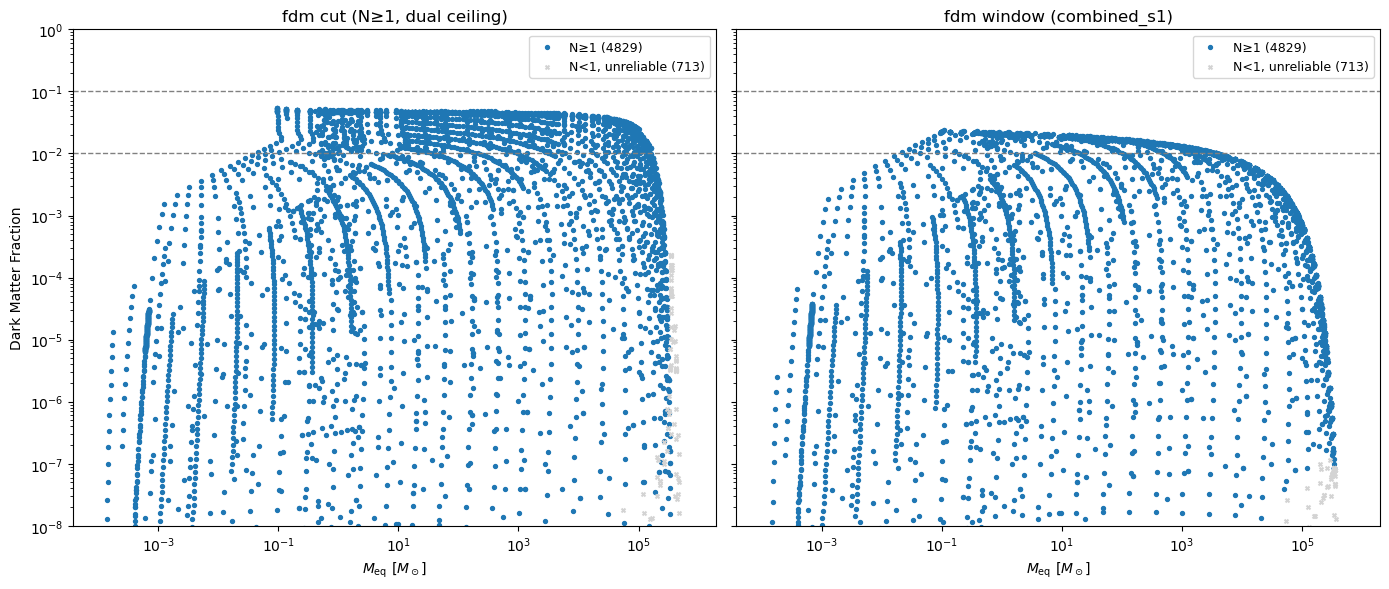

In [66]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

for a, (col, title) in zip(ax, [("fdm_cut_N1","fdm cut (N≥1, dual ceiling)"),
                                 ("fdm_s1","fdm window (combined_s1)")]):
    ok  = d[~d.low_pop]
    low = d[d.low_pop]
    a.scatter(ok["meq_vegas"],  ok[col],  s=8, c="C0", label=f"N≥1 ({len(ok)})")
    a.scatter(low["meq_vegas"], low[col], s=8, c="lightgray", marker="x",
              label=f"N<1, unreliable ({len(low)})")
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel(r"$M_{\rm eq}\ [M_\odot]$")
    a.set_title(title)
    a.set_ylim(1e-8, 1)
    a.legend(fontsize=9)
ax[0].set_ylabel("Dark Matter Fraction")
for a in ax:
    a.axhline(1e-2, ls="--", c="gray", lw=1)
    a.axhline(1e-1, ls="--", c="gray", lw=1)
plt.tight_layout(); plt.show()

Abundance ceiling: N(>M) = 1. The mass where your file's collapsed subhalo cumulative count drops to 1. Above this mass the host expects <1 collapsed subhalo,
 so a smooth-MF f_dm there is meaningless. (Justification: discreteness / Poisson — Hiroshima+2022 O(10⁻²), Diemand+2007 N(>10¹⁰)≈1.)

Mass-ratio ceiling: m/M_host = 0.01 → M = 1.5×10¹⁰ M_sun. The largest mass that's still a subhalo rather than a major merger. (Justification: m/M ≪ 1 subhalo regime; Hiroshima Poisson scale.)

In [67]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- get N onto d (from combined_s1.csv), merged on sigma/omega ---
if "N" in d.columns:
    Nser = pd.to_numeric(d["N"], errors="coerce")
else:
    cpath = "combined_s1.csv" if os.path.exists("combined_s1.csv") else "combined_s1.cvs"
    cs = pd.read_csv(cpath); cs.columns = [c.strip() for c in cs.columns]
    KEYS = ["sigma", "omega"]
    for k in KEYS + ["N"]: cs[k] = pd.to_numeric(cs[k], errors="coerce")
    for k in KEYS:         d[k]  = pd.to_numeric(d[k],  errors="coerce")
    cs_small = cs[KEYS + ["N"]].dropna(subset=KEYS).drop_duplicates(KEYS, keep="last")
    d = d.merge(cs_small, on=KEYS, how="left", validate="m:1")
    Nser = pd.to_numeric(d["N"], errors="coerce")
    print(f"[merge N] matched {int(Nser.notna().sum())}/{len(d)}")

d = d.assign(_N=Nser)

# --- discrete color scale for N: 1..14, top = 14+ (matches your earlier plots) ---
bounds = np.arange(0.5, 14.5 + 1, 1)
cmap   = plt.get_cmap("plasma")
norm   = BoundaryNorm(bounds, ncolors=cmap.N, clip=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
sc = None
for a, (col, title) in zip(ax, [("fdm_cut_N1", "fdm cut (N≥1, dual ceiling)"),
                                 ("fdm_s1",     "fdm window (combined_s1)")]):
    ok  = d[~d.low_pop]
    low = d[d.low_pop]
    Nclip = np.clip(np.floor(pd.to_numeric(ok["_N"], errors="coerce")), 1, 14)
    sc = a.scatter(ok["meq_vegas"], ok[col], c=Nclip, s=8, cmap=cmap, norm=norm,
                   label=f"N≥1 ({len(ok)})")
    a.scatter(low["meq_vegas"], low[col], s=8, c="lightgray", marker="x",
              label=f"N<1, unreliable ({len(low)})")
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel(r"$M_{\rm eq}\ [M_\odot]$")
    a.set_title(title); a.set_ylim(1e-8, 1)
    a.axhline(1e-2, ls="--", c="gray", lw=1)
    a.axhline(1e-1, ls="--", c="gray", lw=1)
    a.legend(fontsize=9)
ax[0].set_ylabel("Dark Matter Fraction")

# shared colorbar on the right
div = make_axes_locatable(ax[1])
cax = div.append_axes("right", size="3%", pad=0.15)
cb  = fig.colorbar(sc, cax=cax, ticks=np.arange(1, 15), boundaries=bounds, extend="max")
labs = [str(i) for i in range(1, 15)]
if np.nanmax(pd.to_numeric(d["_N"], errors="coerce")) > 14: labs[-1] = "14+"
cb.ax.set_yticklabels(labs); cb.set_label("Expected events (N)")

plt.tight_layout(); plt.show()

KeyError: 'N'

[merge N] col='N'  matched 1647/5542


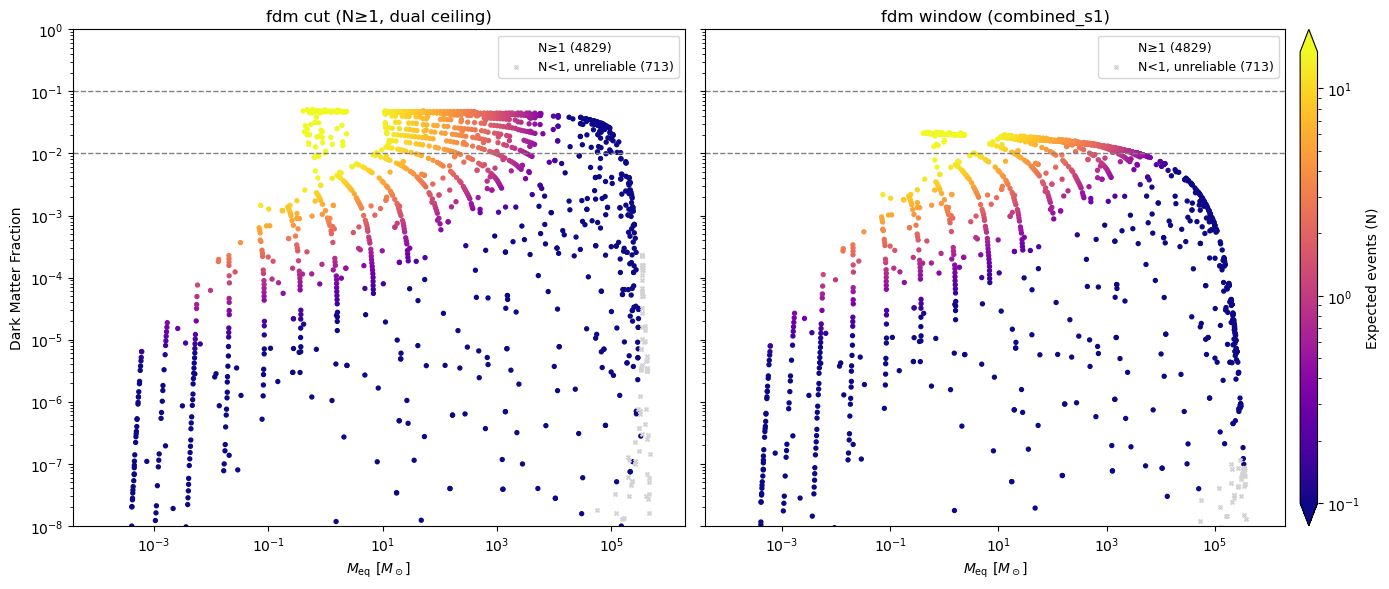

In [68]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- load N from B_combined3.csv, merge onto d on (sigma, omega) ---
NPATH = "B_combined3.csv"
if not os.path.exists(NPATH):
    raise FileNotFoundError(f"{NPATH} not found in {os.getcwd()}.")
nb = pd.read_csv(NPATH); nb.columns = [c.strip() for c in nb.columns]

# pick N column (edit N_COL if autodetect is wrong)
N_COL = next((c for c in ("N", "N_exp", "Nevents", "n_events", "Nev") if c in nb.columns), None)
if N_COL is None:
    raise KeyError(f"No N column in {NPATH}. Columns = {list(nb.columns)}")

KEYS = ["sigma", "omega"]
for k in KEYS + [N_COL]: nb[k] = pd.to_numeric(nb[k], errors="coerce")
for k in KEYS:           d[k]  = pd.to_numeric(d[k],  errors="coerce")
nb_small = (nb[KEYS + [N_COL]].dropna(subset=KEYS)
              .drop_duplicates(KEYS, keep="last").rename(columns={N_COL: "_N"}))

d = d.drop(columns=[c for c in ("_N",) if c in d.columns]).merge(
        nb_small, on=KEYS, how="left", validate="m:1")
print(f"[merge N] col='{N_COL}'  matched {int(d['_N'].notna().sum())}/{len(d)}")

# --- continuous log color scale 0.1 -> 15 ---
norm = LogNorm(vmin=1e-1, vmax=15)
cmap = plt.get_cmap("plasma")

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
sc = None
for a, (col, title) in zip(ax, [("fdm_cut_N1", "fdm cut (N≥1, dual ceiling)"),
                                 ("fdm_s1",     "fdm window (combined_s1)")]):
    ok  = d[~d.low_pop]
    low = d[d.low_pop]
    Nc  = pd.to_numeric(ok["_N"], errors="coerce").clip(1e-1, 15)
    sc = a.scatter(ok["meq_vegas"], ok[col], c=Nc, s=8, cmap=cmap, norm=norm,
                   label=f"N≥1 ({len(ok)})")
    a.scatter(low["meq_vegas"], low[col], s=8, c="lightgray", marker="x",
              label=f"N<1, unreliable ({len(low)})")
    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel(r"$M_{\rm eq}\ [M_\odot]$")
    a.set_title(title); a.set_ylim(1e-8, 1)
    a.axhline(1e-2, ls="--", c="gray", lw=1)
    a.axhline(1e-1, ls="--", c="gray", lw=1)
    a.legend(fontsize=9)
ax[0].set_ylabel("Dark Matter Fraction")

div = make_axes_locatable(ax[1])
cax = div.append_axes("right", size="3%", pad=0.15)
cb  = fig.colorbar(sc, cax=cax, extend="both")
cb.set_label("Expected events (N)")

plt.tight_layout(); plt.show()

[merge N] col='N'  matched 1647/5542
[fdm_cut_N1] n=1585  a0=3.112 a1=0.846 a2=-0.287 a3=-0.105
[fdm_s1] n=1585  a0=3.467 a1=0.987 a2=-0.360 a3=-0.055


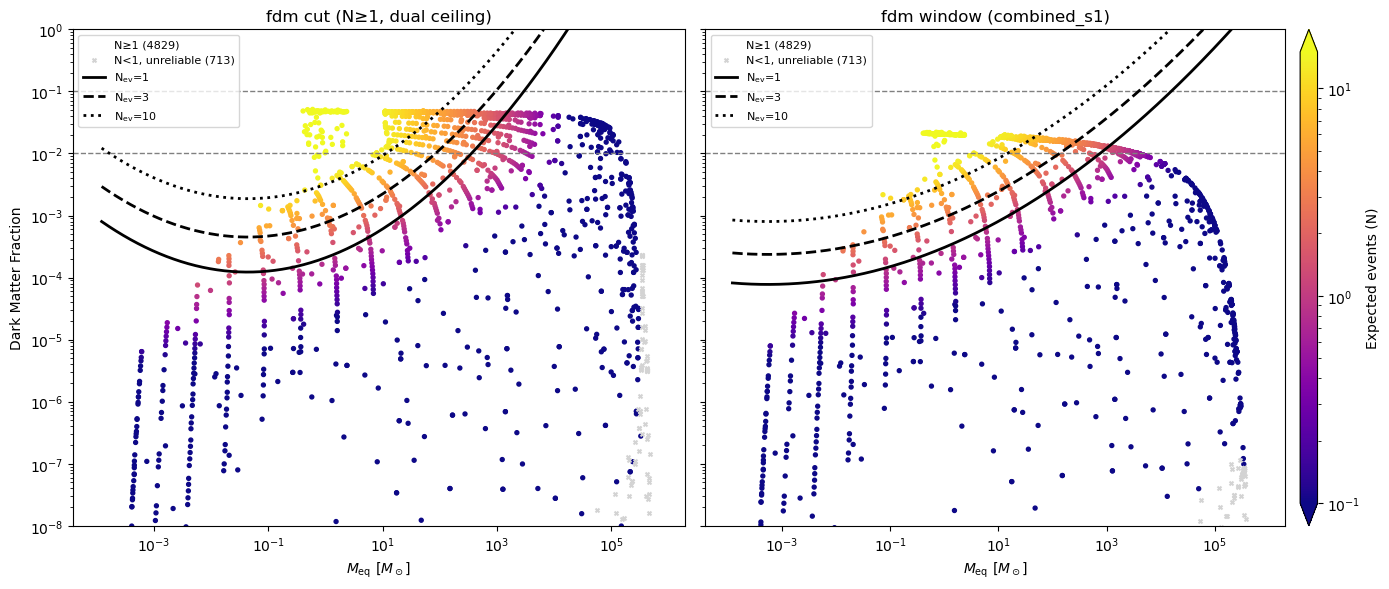

In [ ]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- N_events from B_combined3.csv, merged on (sigma, omega) ---
NPATH = "B_combined3.csv"
if not os.path.exists(NPATH):
    raise FileNotFoundError(f"{NPATH} not found in {os.getcwd()}.")
nb = pd.read_csv(NPATH); nb.columns = [c.strip() for c in nb.columns]
N_COL = next((c for c in ("N","N_exp","Nevents","n_events","Nev") if c in nb.columns), None)
if N_COL is None:
    raise KeyError(f"No N column in {NPATH}. Columns = {list(nb.columns)}")

KEYS = ["sigma","omega"]
for k in KEYS + [N_COL]: nb[k] = pd.to_numeric(nb[k], errors="coerce")
for k in KEYS:           d[k]  = pd.to_numeric(d[k],  errors="coerce")
nb_small = (nb[KEYS+[N_COL]].dropna(subset=KEYS)
              .drop_duplicates(KEYS, keep="last").rename(columns={N_COL:"_N"}))
d = d.drop(columns=[c for c in ("_N",) if c in d.columns]).merge(
        nb_small, on=KEYS, how="left", validate="m:1")
print(f"[merge N] col='{N_COL}'  matched {int(d['_N'].notna().sum())}/{len(d)}")

# --- fit logN = a0 + a1 logf + a2 logM + a3 logM^2, invert for f(M; N) ---
def fit_and_contour(M, F, N, logM_grid, levels):
    m = (np.isfinite(M)&np.isfinite(F)&np.isfinite(N)&(M>0)&(F>0)&(N>0))
    lM, lF, lN = np.log10(M[m]), np.log10(F[m]), np.log10(N[m])
    X = np.column_stack([np.ones_like(lM), lF, lM, lM**2])
    a0,a1,a2,a3 = np.linalg.lstsq(X, lN, rcond=None)[0]
    if not np.isfinite(a1) or abs(a1) < 1e-2:
        print(f"  warn: a1~0 ({a1:.2e}); contours unreliable")
    out = {}
    for L in levels:                       # logf = (logN - a0 - a2 logM - a3 logM^2)/a1
        out[L] = (np.log10(L) - a0 - a2*logM_grid - a3*logM_grid**2) / a1
    return (a0,a1,a2,a3), out, int(m.sum())

LEVELS = [1, 3, 10]
LSTYLE = {1:"-", 3:"--", 10:":"}
norm = LogNorm(vmin=1e-1, vmax=15); cmap = plt.get_cmap("plasma")

fig, ax = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)
sc = None
for a, (col, title) in zip(ax, [("fdm_cut_N1","fdm cut (N≥1, dual ceiling)"),
                                 ("fdm_s1",    "fdm window (combined_s1)")]):
    ok  = d[~d.low_pop]; low = d[d.low_pop]
    Nc  = pd.to_numeric(ok["_N"], errors="coerce").clip(1e-1, 15)
    sc = a.scatter(ok["meq_vegas"], ok[col], c=Nc, s=8, cmap=cmap, norm=norm,
                   label=f"N≥1 ({len(ok)})")
    a.scatter(low["meq_vegas"], low[col], s=8, c="lightgray", marker="x",
              label=f"N<1, unreliable ({len(low)})")

    # fit on this panel's own y-column (use the population-reliable rows only)
    M = pd.to_numeric(ok["meq_vegas"], errors="coerce").to_numpy(float)
    F = pd.to_numeric(ok[col],         errors="coerce").to_numpy(float)
    Nv= pd.to_numeric(ok["_N"],        errors="coerce").to_numpy(float)
    fin = np.isfinite(M)&(M>0)
    logM_grid = np.linspace(np.log10(M[fin].min()), np.log10(M[fin].max()), 600)
    beta, contours, npts = fit_and_contour(M, F, Nv, logM_grid, LEVELS)
    print(f"[{col}] n={npts}  a0={beta[0]:.3f} a1={beta[1]:.3f} "
          f"a2={beta[2]:.3f} a3={beta[3]:.3f}")
    Mline = 10**logM_grid
    for L in LEVELS:
        Fline = 10**contours[L]
        keep = (Fline > 1e-8) & (Fline < 1.0)
        a.plot(Mline[keep], Fline[keep], color="k", lw=2.0, ls=LSTYLE[L],
               zorder=5, label=f"N$_{{\\rm ev}}$={L}")

    a.set_xscale("log"); a.set_yscale("log")
    a.set_xlabel(r"$M_{\rm eq}\ [M_\odot]$")
    a.set_title(title); a.set_ylim(1e-8, 1)
    a.axhline(1e-2, ls="--", c="gray", lw=1); a.axhline(1e-1, ls="--", c="gray", lw=1)
    a.legend(fontsize=8)
ax[0].set_ylabel("Dark Matter Fraction")

div = make_axes_locatable(ax[1]); cax = div.append_axes("right", size="3%", pad=0.15)
cb = fig.colorbar(sc, cax=cax, extend="both"); cb.set_label("Expected events (N)")
plt.tight_layout(); plt.show()
# events per year 

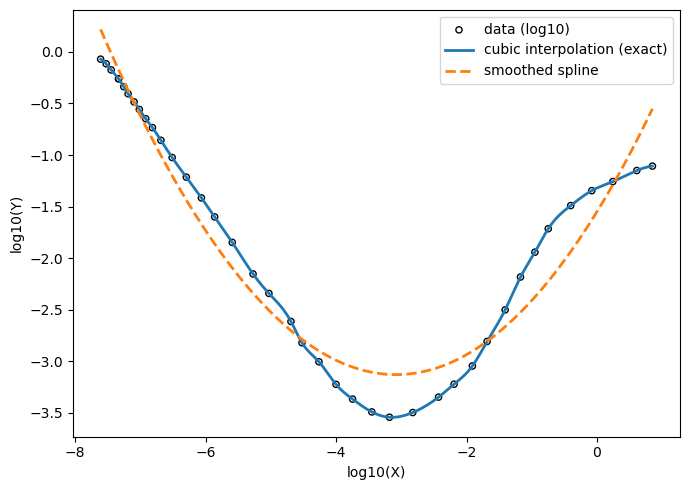

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, UnivariateSpline

# --- read & clean ---
df = pd.read_csv("Djuna_con.csv")
df.rename(columns=lambda c: c.strip(), inplace=True)

# x,y are already log10 values (exponents)
x = pd.to_numeric(df["x"], errors="coerce")
y = pd.to_numeric(df["y"], errors="coerce")
m = np.isfinite(x) & np.isfinite(y)
x, y = x[m], y[m]

# --- collapse duplicate x by averaging y (could also use 'median') ---
g = pd.DataFrame({"x": x, "y": y}).groupby("x", as_index=False).mean()
xu = g["x"].to_numpy()
yu = g["y"].to_numpy()

# sort by x
ordr = np.argsort(xu)
xu, yu = xu[ordr], yu[ordr]

# safety: need at least 4 points for cubic; otherwise fall back to linear
kind = "cubic" if xu.size >= 4 else "linear"

# --- exact pass-through interpolation ---
f_exact = interp1d(xu, yu, kind=kind, bounds_error=False, fill_value="extrapolate")

# --- smoothed spline (nice for forecasting / de-noising) ---
# choose smoothing s heuristically; increase s for more smoothing
# here we scale by data variance and number of points
s = 0.25 * xu.size * np.var(yu)   # tweak 0.25 ↔ 2.0 to taste
k = min(3, xu.size - 1)           # spline order
spl = UnivariateSpline(xu, yu, k=k, s=s)

# dense grid for plotting
x_dense = np.linspace(xu.min(), xu.max(), 600)
y_exact = f_exact(x_dense)
y_smooth = spl(x_dense)

# --- plot ---
plt.figure(figsize=(7,5))
plt.scatter(x, y, s=20, facecolors='none', edgecolors='k', label="data (log10)")
plt.plot(x_dense, y_exact, lw=2, label=f"{kind} interpolation (exact)")
plt.plot(x_dense, y_smooth, lw=2, linestyle='--', label="smoothed spline")
plt.xlabel("log10(X)")
plt.ylabel("log10(Y)")
plt.legend()
plt.tight_layout()
plt.show()


In [79]:
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

def build_interpolator(csv_file):
    """
    Reads a CSV with columns 'x' and 'y' (already in log10),
    removes duplicates by averaging, and returns a cubic interpolation function.
    """
    # Read and clean
    df = pd.read_csv(csv_file)
    df.rename(columns=lambda c: c.strip(), inplace=True)
    x = pd.to_numeric(df["x"], errors="coerce")
    y = pd.to_numeric(df["y"], errors="coerce")
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    
    # Collapse duplicates
    g = pd.DataFrame({"x": x, "y": y}).groupby("x", as_index=False).mean()
    xu = g["x"].to_numpy()
    yu = g["y"].to_numpy()
    
    # Sort
    order = np.argsort(xu)
    xu, yu = xu[order], yu[order]
    
    # Build cubic interpolation
    kind = "cubic" if xu.size >= 4 else "linear"
    f_interp = interp1d(xu, yu, kind=kind, bounds_error=False, fill_value="extrapolate")
    
    return f_interp

# Example usage:
interp_func_D = build_interpolator("Djuna_con.csv")

# Get interpolated y for a given m (log10 space)
m_value = -3.5
y_value = interp_func_D(m_value)
print(f"Interpolated log10(Y) at m={m_value}: {y_value}")


Interpolated log10(Y) at m=-3.5: -3.4732247609874056


In [80]:
COLORS = odict([
    ('blue','#1F77B4'),  # This is original T10 "tab:blue"
    ('gray','#7F7F7F'),  # This is original T10 "tab:gray"
    ('orange','orange'),
    ('gold','orange'),
    ('red','#FA0303'),   # T10 color is #D62728
    ('black','k'),   # T10 color is #D62728
])
ALPHA = 0.35
LINEWIDTH = 2

DEFAULTS = dict(color=COLORS['blue'],alpha=ALPHA,linewidth=LINEWIDTH)

def get_datadir():
    """Get the data directory. Could live here or up one level."""
    if os.path.exists('./data'):
        return './data'
    elif os.path.exists('../data'):
        return '../data'
    else:
        raise IOError("Data directory not found.")

def get_datafile(filename):
    """Get a data file."""
    datadir = get_datadir()
    path = os.path.join(datadir,filename)
    if not os.path.exists(path):
        raise IOError("Data file not found: %s"%path)
    return path

def setdefaults(kwargs,defaults):
    for k,v in defaults.items():
        kwargs.setdefault(k,v)
    return kwargs

def get_mass_limit(data):
    mass,limit = np.genfromtxt(StringIO(data['xystring'])).T
    if data.get('mass_unit') == 'gram':
        mass /= 2e33
    elif data.get('mass_unit') == 'tev':
         mass *= 1e3
    return mass, limit

def plot_text(data):
    kwargs = dict(ha='center',  va='top', rotation=data.get('rotation',0))
    return plt.text(float(data['label_x']),
                    float(data['label_y']),
                    data['style']['label'],
                    **kwargs
                    )

def plot_limit(data):
    mass,limit = get_mass_limit(data)
    kwargs = dict(**data['style'])
    plt.plot(mass, limit, **kwargs)
    plot_text(data)

def plot_limit_fill(data, low=False):
    mass,limit = get_mass_limit(data)

    kwargs = dict(**data['style'])
    setdefaults(kwargs,DEFAULTS)

    plt.fill_between(mass, limit, y2 = 1 if not low else 0,
                     edgecolor=kwargs['color'],
                     facecolor=kwargs['color'],
                     alpha=kwargs['alpha'],
    )
    #plot_text(data)


def plot_lsst_limit(data, low=False):
    kwargs = dict(**data['style'])
    setdefaults(kwargs,DEFAULTS)

    mass,limit = get_mass_limit(data)
    kwargs['alpha'] = 0.15
    plt.fill_between(mass, limit, y2 = 1 if not low else 0,
                     edgecolor=kwargs['color'],
                     facecolor=kwargs['color'],
                     #facecolor='none', hatch = '/',
                     alpha=kwargs['alpha'],
    )
    #plot_text(data)

    kwargs['alpha'] = 1
    plt.plot(mass, limit, **kwargs)


def plot_limit_patch(data):
    kwargs = dict(**data['style'])
    setdefaults(kwargs,DEFAULTS)

    mass,limit = get_mass_limit(data)
    patch = PathPatch(Path(zip(mass, limit)),
                      edgecolor=kwargs['color'],
                      facecolor=kwargs['color'],
                     alpha=kwargs['alpha'])
    plt.gca().add_artist(patch)
    plot_text(data)

def plot_one(data):
    kwargs = dict(**data['style'])
    setdefaults(kwargs,DEFAULTS)

    mass,limit = get_mass_limit(data)
    plt.fill_between(mass, limit, y2=1.0,
                     edgecolor=COLORS['gray'],
                     facecolor=COLORS['gray'],
                     alpha=kwargs['alpha'])
    #plot_text(data)

def plot_two(data_loose, data_tight):
    kwargs = dict(**data_loose['style'])
    setdefaults(kwargs,DEFAULTS)

    mass_loose,limit_loose = get_mass_limit(data_loose)
    mass_tight,limit_tight = get_mass_limit(data_tight)

    # Interpolate the data to a common grid
    x_min = np.min((np.min(mass_loose), np.min(mass_tight)))
    x_max = np.max((np.max(mass_loose), np.max(mass_tight)))
    x = np.logspace(np.log10(x_min), np.log10(x_max), num=100)
    limit_loose_interp = np.interp(x, mass_loose, limit_loose)
    limit_tight_interp = np.interp(x, mass_tight, limit_tight)

    plt.fill_between(mass_loose, limit_loose, y2=1.0,
                     edgecolor=COLORS['blue'],
                     facecolor=COLORS['blue'],
                     alpha=kwargs['alpha'])
    plt.fill_between(x, limit_tight_interp, limit_loose_interp,
                     edgecolor='k',
                     linewidth=0,
                     facecolor='k',
                     alpha=0.07)
    plot_text(data_loose)

In [81]:
def logsense(m,m0,mr):
    return 1.0/(1.0 + (m/m0)**(-1.0/mr))


newconstraints = np.loadtxt('test.txt')
#DDconstraints = np.power(10, np.loadtxt('Dark-Disk/rescaled_DD_mass_q1.0.txt'))*0.06  same data new file name so import works 
DDconstraints = np.power(10, np.loadtxt('test-copy.txt'))*0.06
M = np.logspace(-4, 7, num = 20)

newconstraints = newconstraints/logsense(M,1e-2,0.5)
DDconstraints = DDconstraints/logsense(M,1e-2,0.5)

M = np.append(3e-5, M)
newconstraints = np.append(1, newconstraints)
DDconstraints = np.append(1, DDconstraints)

/var/folders/t0/lct46439705461yqnjg81yhc0000gp/T/ipykernel_40082/3556725540.py:95: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('retina')


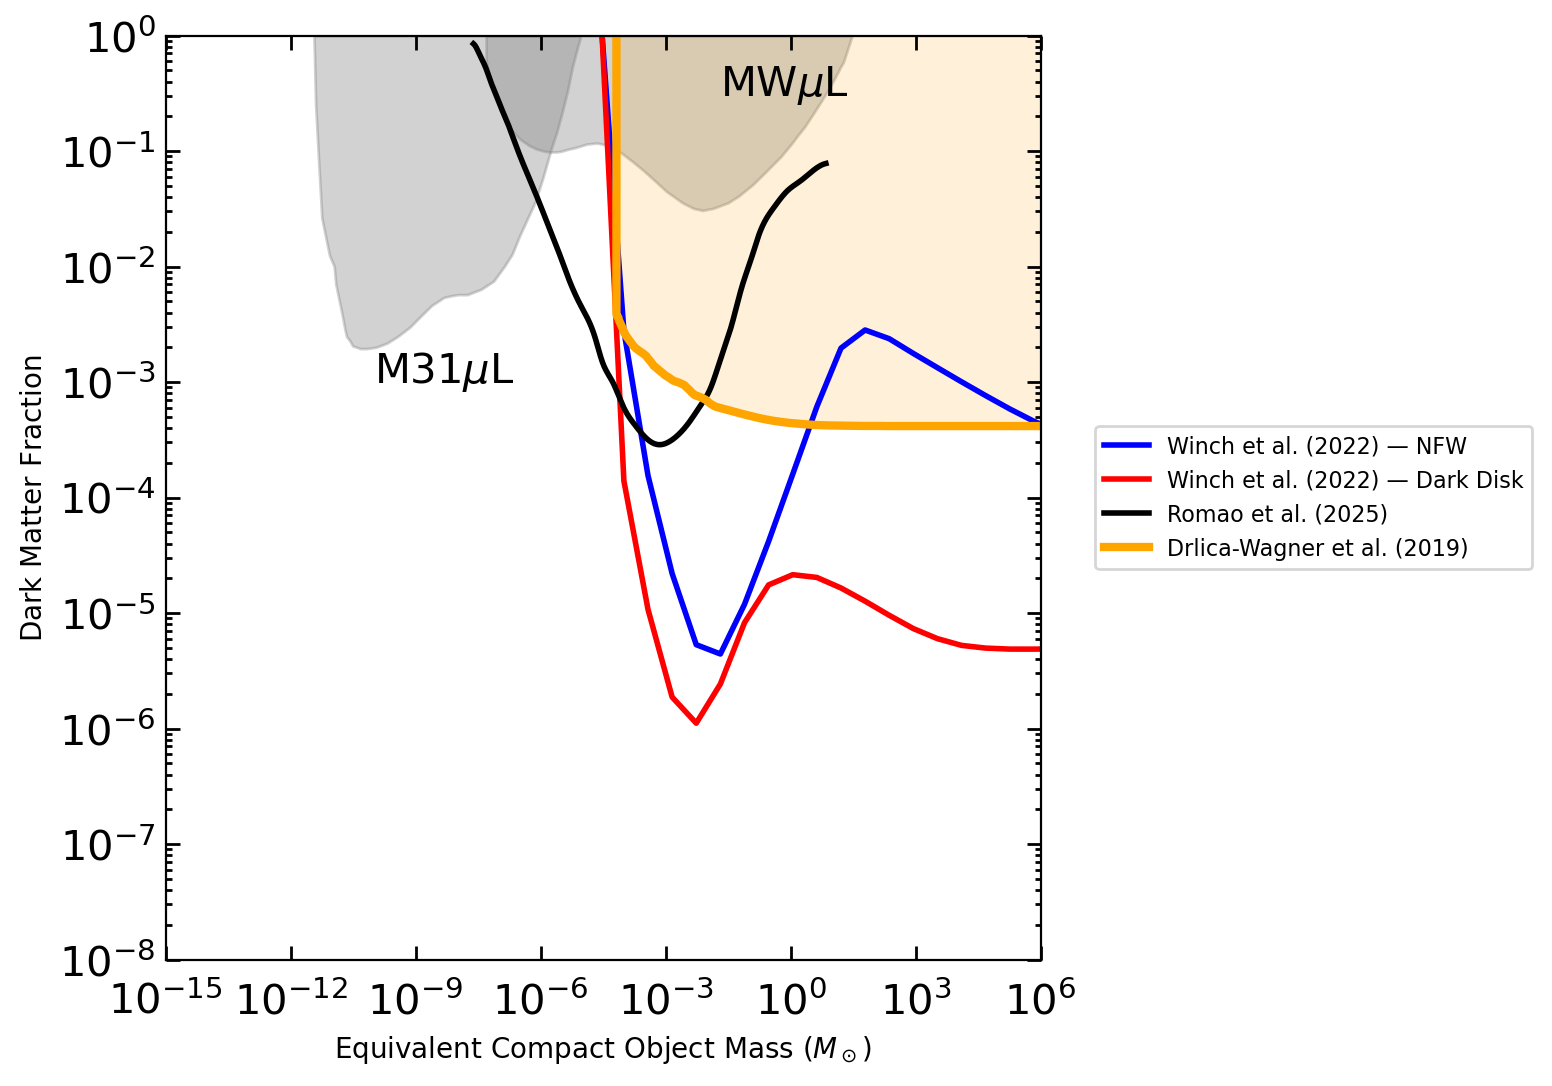

In [85]:
limits = yaml.load(open('macho_limits.yaml'), Loader=yaml.Loader) 
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_xscale('log')
ax.set_yscale('log')
# Orange curve – Drlica-Wagner et al. (2019)
plot_one(limits['hsc_niikura_2017'])
#ax.plot([], [], color='orange', lw=2, label='Drlica-Wagner et al. (2019)')

# EROS curve (leave as is if no year needed)
plot_one(limits['eros_tisserand_2007'])

# LSST microlensing limit (orange inside function – keep or remove label if duplicate)
#plot_lsst_limit(limits['lsst_microlensing'])

# Blue – Winch et al. (2022)
ax.plot(M, newconstraints, lw=2, c='b', label='Winch et al. (2022) — NFW')

# Red – Winch et al. (2022)
ax.plot(M, DDconstraints, lw=2, c='r', label='Winch et al. (2022) — Dark Disk')
# Build an m-grid from the CSV’s x-range (to avoid wild extrapolation)
_x = pd.read_csv("Djuna_con.csv").rename(columns=lambda c: c.strip())[['x']] \
        .apply(pd.to_numeric, errors='coerce').dropna().to_numpy().ravel()
m_grid = np.linspace(_x.min(), _x.max(), 600)

# Black – 2025 (only plot once)
ax.plot(10**m_grid, 10**interp_func_D(m_grid), lw=2, color='k', label='Romao et al. (2025)')
plot_lsst_limit(limits['lsst_microlensing'])  # draws

# before the call, remember what's already on the legend
h0, _ = ax.get_legend_handles_labels()
# find the NEW artists the function just added
h1, _ = ax.get_legend_handles_labels()
new = [h for h in h1 if h not in h0]

# hide labels on all of them, then give one the label you want
for h in new:
    h.set_label('_nolegend_')
if new:
    new[-1].set_label(r"LSST microlensing (forecast)")

# rebuild a de-duplicated legend
handles, labels = ax.get_legend_handles_labels()
seen, H, L = set(), [], []
for h, l in zip(handles, labels):
    if l in ('', '_nolegend_') or l in seen:  # drop hidden/duplicates
        continue
    seen.add(l); H.append(h); L.append(l)

ax.legend(H, L, loc='best')


ax = plt.gca()
for group in (ax.lines, ax.patches, ax.collections):
    if group:                        # pick the last thing that was added
        group[-1].set_label(r"Drlica-Wagner et al. (2019)")
        break

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='best')

# Text labels
ax.text(2e-2, 3e-1, 'MW$\mu$L')
ax.text(1e-10, 1e-3, 'M31$\mu$L')

# Formatting
ax.set_xlim(1e-15, 1e6)
ax.set_ylim(1e-8, 1)
ax.set_xlabel(r'${\rm Equivalent\  Compact\ Object\ Mass}\ (M_\odot)$', fontsize=10)
ax.set_ylabel(r'${\rm Dark\ Matter\ Fraction}$', fontsize=10)

plt.subplots_adjust(right=0.75)

#labels = [f"σ={s:.2e}, ω={w:.2e}" for s, w in zip(sigmas, omegas)]


''' 
# Add labels next to each point
for xm, ym, label in zip(meqs, fdms, labels):
    ax.annotate(label,
                (xm, ym),
                xytext=(5, 2), textcoords="offset points",
                fontsize=7) 
ax.scatter(meqs, fdms, s=40, alpha=0.8, edgecolor="none")
# Legend
'''

#delta = dNFW  # e.g. offsets vs NFW in dex
#idx = np.argsort(delta)[::-1]           # largest first
#topK = idx[:25]                         # label top 25
# or: topK = np.where(delta > 0.5)[0]   # label those ≥0.5 dex above

#ax.scatter(meqs, fdms, s=18, alpha=0.7)
ax.legend(loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=8)

set_matplotlib_formats('retina')
plt.show()

In [90]:
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

# ---------- robust PCHIP in log-log ----------
def _pchip_logfunc(M, F, *, dedup_rtol=1e-12):
    """Return f(Mq) that evaluates log–log PCHIP and NaNs outside [min(M), max(M)]."""
    M = np.asarray(M, float); F = np.asarray(F, float)
    m = np.isfinite(M) & np.isfinite(F) & (M > 0) & (F > 0)
    M, F = M[m], F[m]
    if M.size < 2: raise ValueError("need ≥2 finite positive points")

    # sort and collapse near-duplicate x to enforce strictly increasing
    i = np.argsort(M); M, F = M[i], F[i]
    Mu, Fu = [M[0]], [F[0]]
    for x, y in zip(M[1:], F[1:]):
        if np.isclose(x, Mu[-1], rtol=dedup_rtol):
            # keep the tighter (smaller) limit by default
            Fu[-1] = min(Fu[-1], y)
        else:
            Mu.append(x); Fu.append(y)
    Mu, Fu = np.array(Mu), np.array(Fu)
    if Mu.size < 2: raise ValueError("after dedup, need ≥2 x points")

    xlog = np.log10(Mu)
    ylog = np.log10(Fu)
    interp = PchipInterpolator(xlog, ylog, extrapolate=False)
    xmin, xmax = Mu.min(), Mu.max()

    def f(Mq):
        Mq = np.asarray(Mq, float)
        out = np.full_like(Mq, np.nan, dtype=float)
        mdom = (Mq > 0) & (Mq >= xmin) & (Mq <= xmax)
        if mdom.any():
            out[mdom] = 10.0**interp(np.log10(Mq[mdom]))
        return out

    # attach metadata (handy for debugging/plotting)
    f.xmin, f.xmax = float(xmin), float(xmax)
    return f

# ---------- parse YAML "limits" entries no matter how they store xy ----------
def _xy_from_limit_entry(entry):
    """
    Accepts common MACHO YAML shapes:
      - {'x':[...], 'y':[...]}
      - {'xy': [[x,y], ...]}
      - {'xystring': 'x y\\n...'}
    Returns linear M, F.
    """
    if isinstance(entry, dict):
        if 'x' in entry and 'y' in entry:
            M = np.asarray(entry['x'], float); F = np.asarray(entry['y'], float)
            return M, F
        if 'xy' in entry:
            arr = np.asarray(entry['xy'], float)
            return arr[:,0], arr[:,1]
        if 'xystring' in entry:
            rows = []
            for line in str(entry['xystring']).strip().splitlines():
                parts = line.strip().split()
                if len(parts) >= 2:
                    try:
                        rows.append((float(parts[0]), float(parts[1])))
                    except Exception:
                        pass
            if rows:
                arr = np.asarray(rows, float)
                return arr[:,0], arr[:,1]
    raise KeyError(f"Could not find x–y data in entry; keys={list(entry.keys())}")

# ---------- build one curve from a limits[...] item ----------
def curve_from_limits_entry(limits, key, label=None):
    M, F = _xy_from_limit_entry(limits[key])
    f = _pchip_logfunc(M, F)
    f.label = label or key
    return f

# ---------- Romão (2025) from CSV with log10 columns x,y ----------
def curve_from_romao_csv(csv_path, label="Romão et al. (2025)"):
    df = pd.read_csv(csv_path).rename(columns=lambda c: c.strip())
    # Expect columns 'x' (log10 M) and 'y' (log10 f)
    xlog = pd.to_numeric(df['x'], errors='coerce').to_numpy()
    ylog = pd.to_numeric(df['y'], errors='coerce').to_numpy()
    m = np.isfinite(xlog) & np.isfinite(ylog)
    xlog, ylog = xlog[m], ylog[m]
    i = np.argsort(xlog); xlog, ylog = xlog[i], ylog[i]
    interp = PchipInterpolator(xlog, ylog, extrapolate=False)
    xmin, xmax = 10**xlog.min(), 10**xlog.max()

    def f(Mq):
        Mq = np.asarray(Mq, float)
        out = np.full_like(Mq, np.nan, dtype=float)
        mdom = (Mq > 0) & (Mq >= xmin) & (Mq <= xmax)
        if mdom.any():
            out[mdom] = 10.0**interp(np.log10(Mq[mdom]))
        return out
    f.xmin, f.xmax, f.label = float(xmin), float(xmax), label
    return f

# ---------- Winch et al. (2022): arrays already in linear space ----------
def curve_from_arrays(M, F, label):
    return _pchip_logfunc(M, F)

# ---------- build everything you’re plotting ----------
def build_all_curve_functions(limits, M, newconstraints, DDconstraints, romao_csv_path):
    curves = {}
    curves["HSC (Niikura et al. 2017)"] = curve_from_limits_entry(limits, 'hsc_niikura_2017',
                                                                  label="HSC (Niikura et al. 2017)")
    curves["EROS (Tisserand et al. 2007)"] = curve_from_limits_entry(limits, 'eros_tisserand_2007',
                                                                     label="EROS (Tisserand et al. 2007)")
    curves["LSST microlensing (forecast)"] = curve_from_limits_entry(limits, 'lsst_microlensing',
                                                                     label="LSST microlensing (forecast)")
    f_nfw = curve_from_arrays(M, newconstraints, "Winch et al. (2022) — NFW");    f_nfw.label = "Winch et al. (2022) — NFW"
    f_dd  = curve_from_arrays(M, DDconstraints,  "Winch et al. (2022) — Dark Disk"); f_dd.label = "Winch et al. (2022) — Dark Disk"
    curves[f_nfw.label] = f_nfw
    curves[f_dd.label]  = f_dd

    curves["Romão et al. (2025)"] = curve_from_romao_csv(romao_csv_path,
                                                         label="Romão et al. (2025)")
    return curves

In [94]:
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator

# ---------- core: build a log–log PCHIP evaluator that NaNs outside domain ----------
def make_curve(x, y, *, x_is_log10=False, y_is_log10=False, dedup_rtol=1e-12, agg="min"):
    """
    x, y: arrays for ONE curve (must be same length).
    x_is_log10 / y_is_log10: set True if your inputs are already log10.
    Returns: f(M) -> y with NaNs outside the curve domain.
    """
    x = np.asarray(x, float); y = np.asarray(y, float)
    if x.shape != y.shape:
        raise ValueError(f"x and y lengths differ: {x.shape} vs {y.shape}")

    # convert to linear if given in log10
    if x_is_log10: x = 10.0**x
    if y_is_log10: y = 10.0**y

    m = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[m], y[m]
    if x.size < 2:
        raise ValueError("need ≥2 finite positive points")

    # sort and deduplicate x so it is strictly increasing
    i = np.argsort(x); x, y = x[i], y[i]
    xu, yu = [x[0]], [y[0]]
    for xi, yi in zip(x[1:], y[1:]):
        if np.isclose(xi, xu[-1], rtol=dedup_rtol):
            # choose tighter (smaller) value by default for upper limits
            yu[-1] = min(yu[-1], yi) if agg == "min" else max(yu[-1], yi)
        else:
            xu.append(xi); yu.append(yi)
    x, y = np.array(xu), np.array(yu)
    if x.size < 2:
        raise ValueError("after dedup, need ≥2 x points")

    interp = PchipInterpolator(np.log10(x), np.log10(y), extrapolate=False)
    xmin, xmax = float(x.min()), float(x.max())

    def f(M):
        M = np.asarray(M, float)
        out = np.full_like(M, np.nan, dtype=float)
        mdom = (M > 0) & (M >= xmin) & (M <= xmax)
        if mdom.any():
            out[mdom] = 10.0**interp(np.log10(M[mdom]))
        return out

    # handy metadata
    f.xmin, f.xmax = xmin, xmax
    return f

# ---------- helpers to extract x,y from your sources ----------
def xy_from_limits_entry(entry):
    if 'x' in entry and 'y' in entry:
        return np.asarray(entry['x'], float), np.asarray(entry['y'], float)
    if 'xy' in entry:
        arr = np.asarray(entry['xy'], float)
        return arr[:,0], arr[:,1]
    if 'xystring' in entry:
        rows = []
        for line in str(entry['xystring']).strip().splitlines():
            parts = line.split()
            if len(parts) >= 2:
                rows.append((float(parts[0]), float(parts[1])))
        arr = np.asarray(rows, float)
        return arr[:,0], arr[:,1]
    raise KeyError(f"limits entry missing x/y data; keys={list(entry.keys())}")

def curve_from_limits(limits, key, label=None):
    x, y = xy_from_limits_entry(limits[key])
    f = make_curve(x, y)
    f.label = label or key
    return f

def curve_from_romao_csv(csv_path, label="Romão et al. (2025)"):
    df = pd.read_csv(csv_path).rename(columns=lambda c: c.strip())
    # CSV has log10 columns named 'x','y'
    xlog = pd.to_numeric(df['x'], errors='coerce').to_numpy()
    ylog = pd.to_numeric(df['y'], errors='coerce').to_numpy()
    f = make_curve(xlog, ylog, x_is_log10=True, y_is_log10=True)
    f.label = label
    return f


In [95]:
# ---------- build one curve from a limits[...] item ----------
def curve_from_limits_entry(limits, key, label=None):
    M, F = _xy_from_limit_entry(limits[key])
    f = _pchip_logfunc(M, F)
    f.label = label or key
    return f

In [96]:
# YAML curves
f_HSC   = curve_from_limits(limits, 'hsc_niikura_2017',  "HSC (Niikura et al. 2017)")
f_EROS  = curve_from_limits(limits, 'eros_tisserand_2007',"EROS (Tisserand et al. 2007)")
f_LSSTF = curve_from_limits(limits, 'lsst_microlensing', "Wager et al. (2019)")

# Winch et al. (2022) — IMPORTANT: use the MASS GRID that produced each y!
# If 'newconstraints' was computed on 'M_winch' and 'DDconstraints' on 'M_winch' as well:
f_NFW = make_curve(M,  newconstraints);  f_NFW.label  = "Winch et al. (2022) — NFW"
f_DD  = make_curve(M,  DDconstraints);   f_DD.label   = "Winch et al. (2022) — Dark Disk"

# Romão 2025 (CSV with log10 columns)
f_ROMAO = curve_from_romao_csv("Djuna_con.csv", "Romão et al. (2025)")

curves = [f_HSC, f_EROS, f_LSSTF, f_NFW, f_DD, f_ROMAO]

[merge N] col='N'  matched 1647/5542
[fit fdm_cut_N1] n=1585  a0=3.112 a1=0.846 a2=-0.287 a3=-0.105


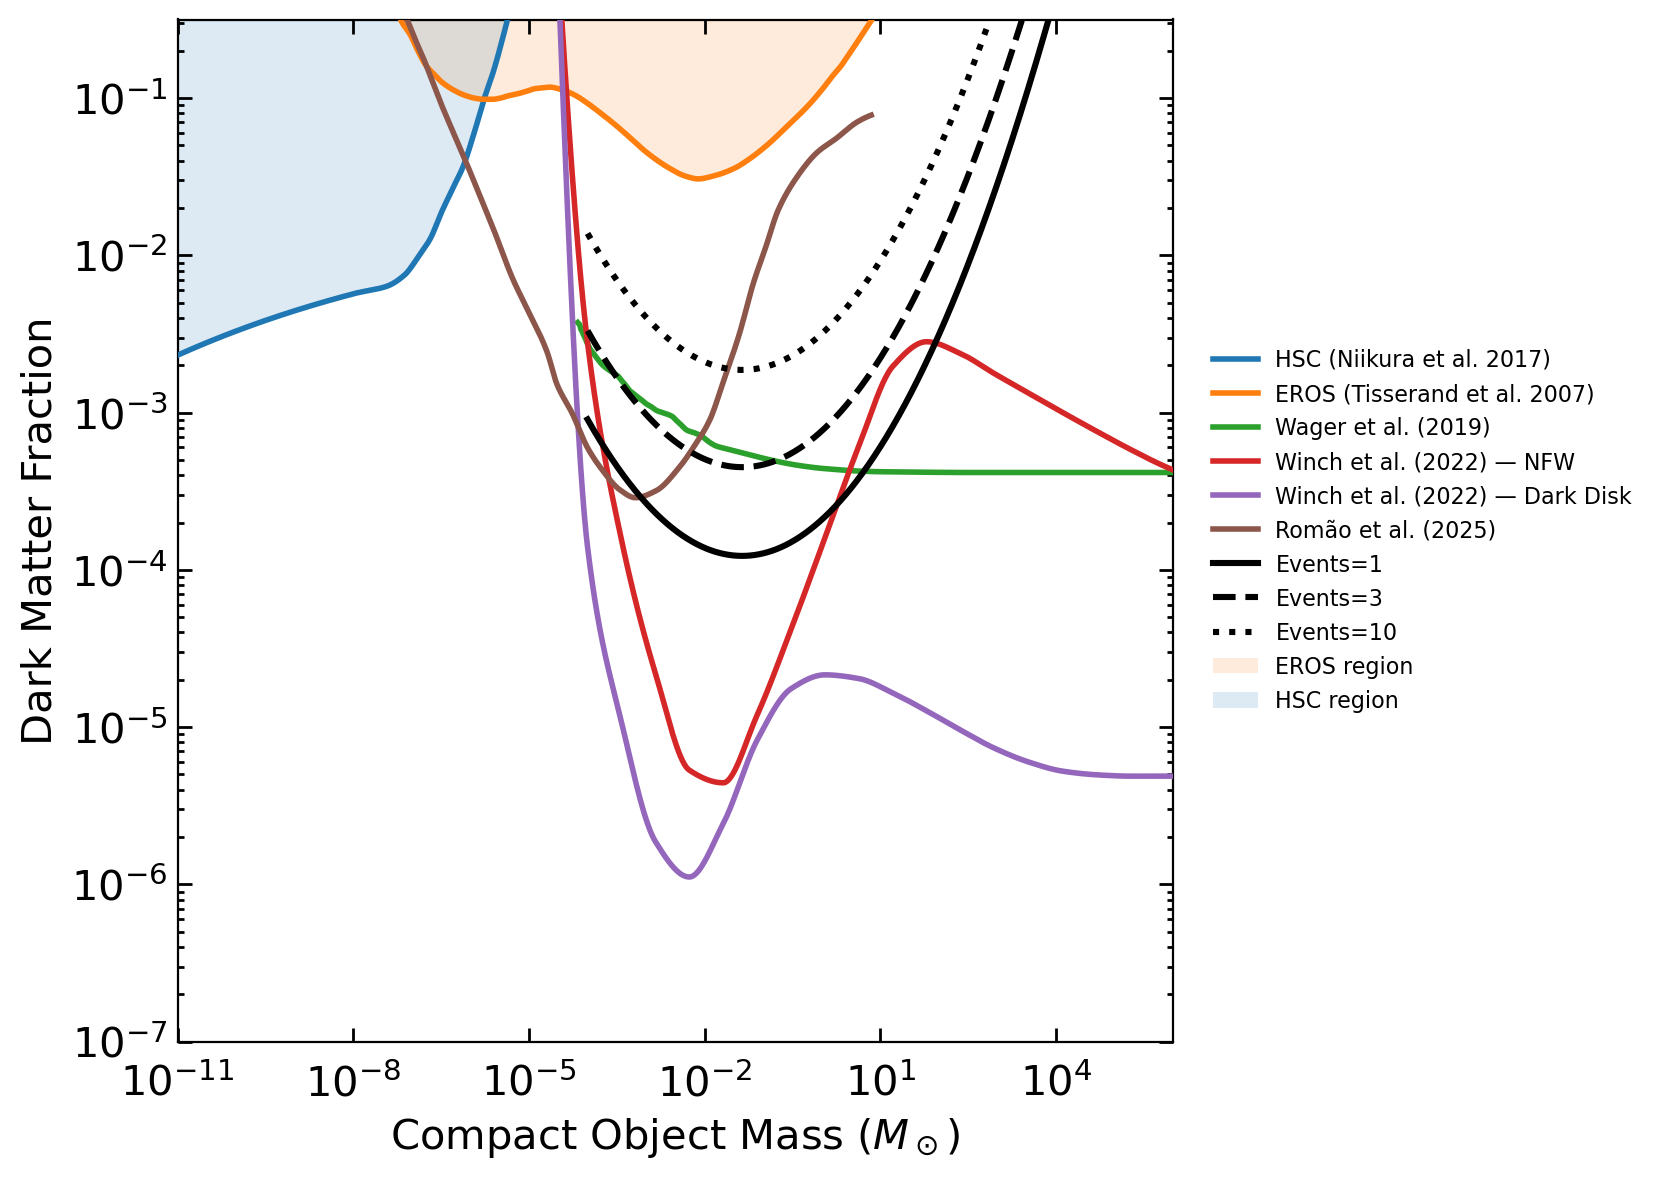

In [98]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------- guards ----------------
if "curves" not in globals():
    raise RuntimeError("`curves` not found.")
if "d" not in globals():
    raise RuntimeError("`d` not found (the frame with meq_vegas, fdm_s1, low_pop).")

# ---------------- N_events from B_combined3.csv, merged on (sigma,omega) ----------------
NPATH = "B_combined3.csv"
if not os.path.exists(NPATH):
    raise FileNotFoundError(f"{NPATH} not found in {os.getcwd()}.")
nb = pd.read_csv(NPATH); nb.columns = [c.strip() for c in nb.columns]
N_COL = next((c for c in ("N","N_exp","Nevents","n_events","Nev") if c in nb.columns), None)
if N_COL is None:
    raise KeyError(f"No N column in {NPATH}. Columns = {list(nb.columns)}")
KEYS = ["sigma","omega"]
for k in KEYS + [N_COL]: nb[k] = pd.to_numeric(nb[k], errors="coerce")
for k in KEYS:           d[k]  = pd.to_numeric(d[k],  errors="coerce")
nb_small = (nb[KEYS+[N_COL]].dropna(subset=KEYS)
              .drop_duplicates(KEYS, keep="last").rename(columns={N_COL:"_N"}))
d = d.drop(columns=[c for c in ("_N",) if c in d.columns]).merge(
        nb_small, on=KEYS, how="left", validate="m:1")
print(f"[merge N] col='{N_COL}'  matched {int(d['_N'].notna().sum())}/{len(d)}")

# ---------------- fit iso-event contours on fdm_s1 (reliable rows only) ----------------
FCOL = "fdm_cut_N1" #"fdm_s1"           # <-- change to "fdm_cut_N1" if you want the cut-panel contours
ok = d[~d.low_pop]
M  = pd.to_numeric(ok["meq_vegas"], errors="coerce").to_numpy(float)
F  = pd.to_numeric(ok[FCOL],         errors="coerce").to_numpy(float)
Nv = pd.to_numeric(ok["_N"],         errors="coerce").to_numpy(float)
m  = np.isfinite(M)&np.isfinite(F)&np.isfinite(Nv)&(M>0)&(F>0)&(Nv>0)
lM, lF, lN = np.log10(M[m]), np.log10(F[m]), np.log10(Nv[m])
X = np.column_stack([np.ones_like(lM), lF, lM, lM**2])
a0,a1,a2,a3 = np.linalg.lstsq(X, lN, rcond=None)[0]
if not np.isfinite(a1) or abs(a1) < 1e-2:
    print(f"warn: a1~0 ({a1:.2e}); contours unreliable")
print(f"[fit {FCOL}] n={m.sum()}  a0={a0:.3f} a1={a1:.3f} a2={a2:.3f} a3={a3:.3f}")

def logF_for_N(logM, N_target):
    return (np.log10(N_target) - a0 - a2*logM - a3*logM**2) / a1

# ---------------- plot (single-panel literature figure) ----------------
Mmin, Mmax = 1e-11, 1e6
Fmin, Fmax = 1e-7, 10**(-0.5)
M_iso_min  = 1e-4                      # black N-lines start here
fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(Mmin, Mmax); ax.set_ylim(Fmin, Fmax)

# 1) literature curves + capture EROS/HSC for shading
M_eval = np.logspace(-15, 6, 2000)
line_handles, line_labels = [], []
eros_xy = hsc_xy = None
for f in curves:
    lab = (getattr(f,"label","") or "").strip()
    yy = f(M_eval); mv = np.isfinite(yy)
    if not mv.any(): continue
    edges = np.where(~mv)[0]; start = 0
    for stop in np.append(edges, len(M_eval)):
        if stop - start > 1:
            (ln,) = ax.plot(M_eval[start:stop], yy[start:stop], lw=2.0, zorder=3)
            if lab and lab not in line_labels:
                ln.set_label(lab); line_labels.append(lab); line_handles.append(ln)
        start = stop + 1
    ll = lab.lower()
    if "eros" in ll: eros_xy = (M_eval[mv], yy[mv])
    if "hsc"  in ll: hsc_xy  = (M_eval[mv], yy[mv])

# 2) fitted iso-event lines, truncated below 1e-4 Msun
levels   = [1, 3, 10]; linestyles = ['-','--',':']  # these are per year, so should *10 
labels_iso = ["Events=1","Events=3","Events=10"]; iso_handles = []
logM_grid = np.linspace(np.log10(M_iso_min), np.log10(Mmax), 1200)
for L, ls, lab in zip(levels, linestyles, labels_iso):
    Mline = 10**logM_grid
    Fline = 10**logF_for_N(logM_grid, L)
    good = (np.isfinite(Fline) & (Fline > Fmin) & (Fline < Fmax) & (Mline >= M_iso_min))
    edges = np.where(~good)[0]; start = 0; first = True
    for stop in np.append(edges, len(Mline)):
        if stop - start > 1:
            (h,) = ax.plot(Mline[start:stop], Fline[start:stop],
                           linestyle=ls, color="k", lw=2.2, zorder=4,
                           label=lab if first else None)
            if first: iso_handles.append(h); first = False
        start = stop + 1

# 3) shade above EROS/HSC
shading_handles = []
for xy, color, name in [(eros_xy,"tab:orange","EROS region"), (hsc_xy,"tab:blue","HSC region")]:
    if xy is None: continue
    x, y = xy; w = np.isfinite(y) & (y > Fmin) & (y < Fmax)
    ax.fill_between(x, y, Fmax, where=w, alpha=0.15, color=color, zorder=1)
    shading_handles.append(mpatches.Patch(facecolor=color, alpha=0.15, label=name))

ax.set_xlabel(r"Compact Object Mass ($M_\odot$)")
ax.set_ylabel("Dark Matter Fraction")
ax.legend(handles=line_handles + iso_handles + shading_handles,
          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

[merge N] col='N'  matched 1647/5542
[fit fdm_cut_N1] n=1585  a0=4.112 a1=0.846 a2=-0.287 a3=-0.105


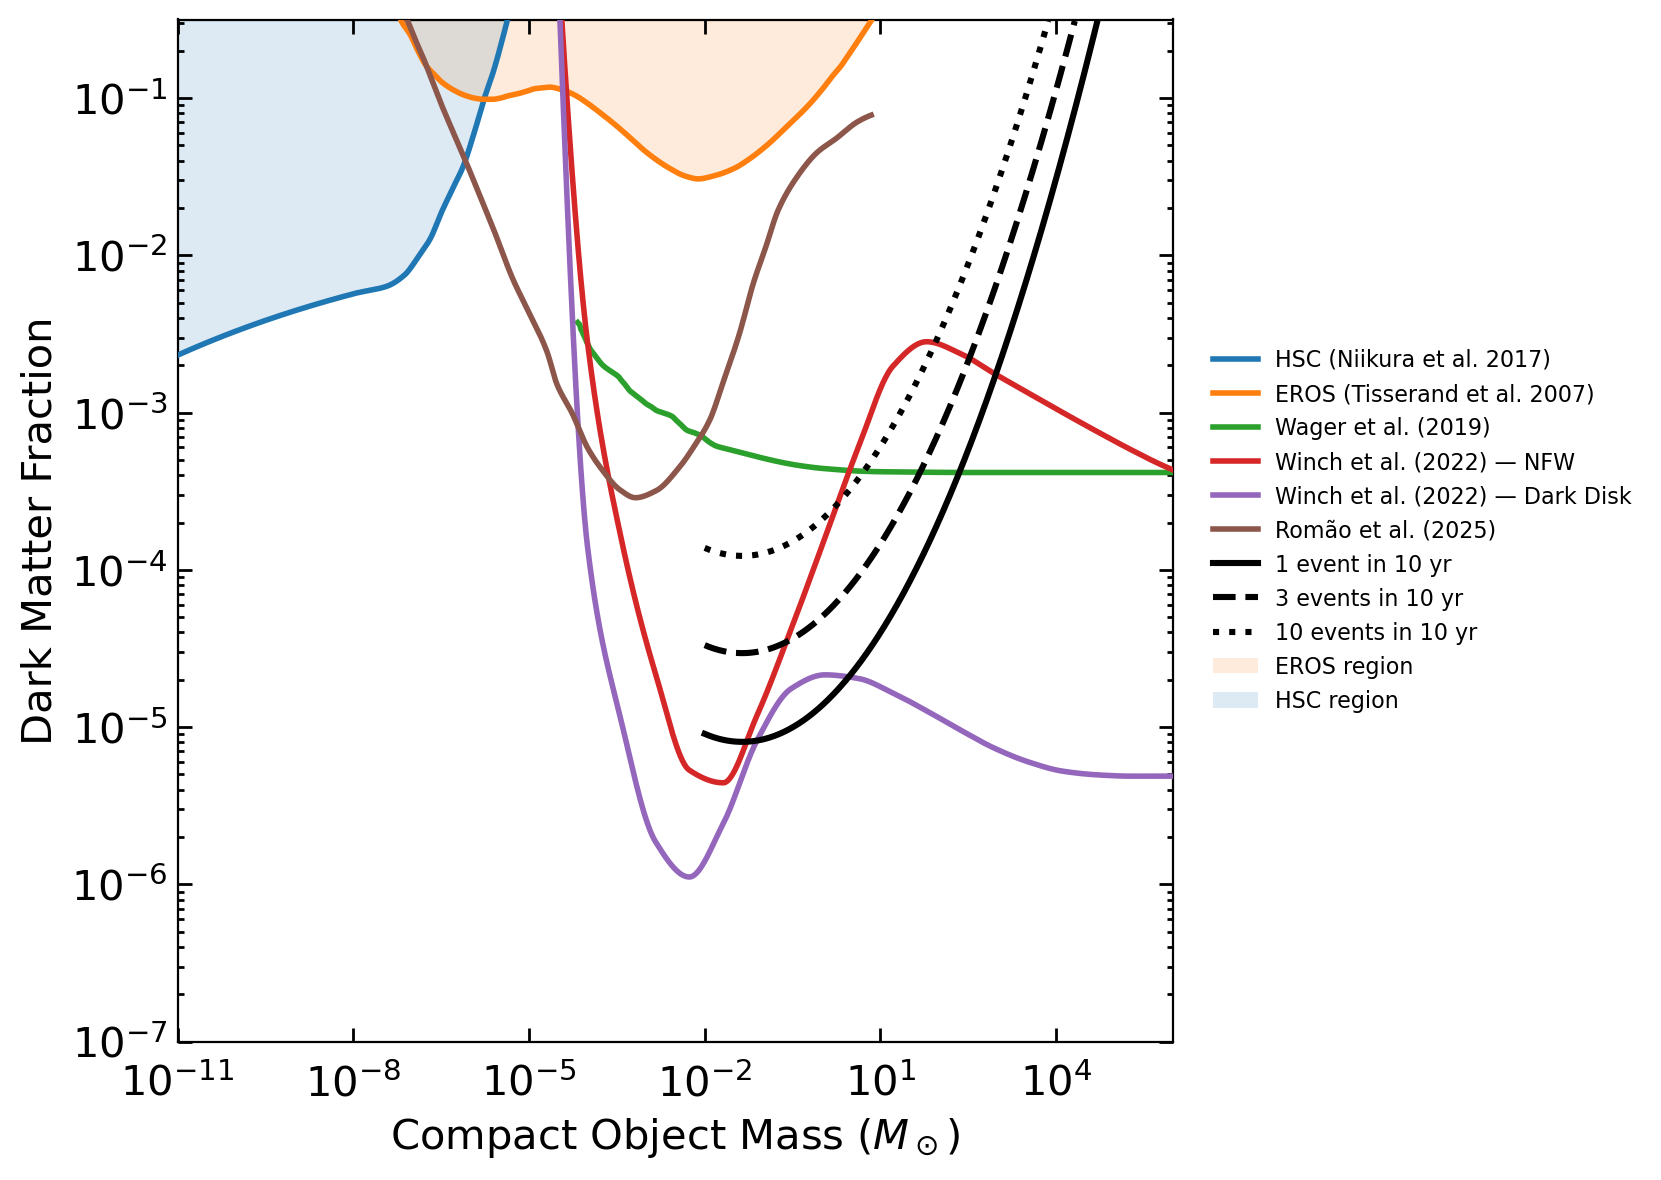

In [99]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------- guards ----------------
if "curves" not in globals(): raise RuntimeError("`curves` not found.")
if "d" not in globals():      raise RuntimeError("`d` not found.")

# ---------------- N_events (per YEAR) from B_combined3.csv ----------------
NPATH = "B_combined3.csv"
if not os.path.exists(NPATH):
    raise FileNotFoundError(f"{NPATH} not found in {os.getcwd()}.")
nb = pd.read_csv(NPATH); nb.columns = [c.strip() for c in nb.columns]
N_COL = next((c for c in ("N","N_exp","Nevents","n_events","Nev") if c in nb.columns), None)
if N_COL is None: raise KeyError(f"No N column in {NPATH}. Columns = {list(nb.columns)}")
KEYS = ["sigma","omega"]
for k in KEYS + [N_COL]: nb[k] = pd.to_numeric(nb[k], errors="coerce")
for k in KEYS:           d[k]  = pd.to_numeric(d[k],  errors="coerce")
nb_small = (nb[KEYS+[N_COL]].dropna(subset=KEYS)
              .drop_duplicates(KEYS, keep="last").rename(columns={N_COL:"_N"}))
d = d.drop(columns=[c for c in ("_N",) if c in d.columns]).merge(
        nb_small, on=KEYS, how="left", validate="m:1")
print(f"[merge N] col='{N_COL}'  matched {int(d['_N'].notna().sum())}/{len(d)}")

# *** UNITS: B_combined3 N is per 1 yr; literature + labels are per 10 yr -> scale x10 ***
YEARS = 10.0
d["_N"] = pd.to_numeric(d["_N"], errors="coerce") * YEARS

# ---------------- fit iso-event contours (reliable rows only) ----------------
FCOL = "fdm_cut_N1"      # or "fdm_s1"
ok = d[~d.low_pop]
M  = pd.to_numeric(ok["meq_vegas"], errors="coerce").to_numpy(float)
F  = pd.to_numeric(ok[FCOL],         errors="coerce").to_numpy(float)
Nv = pd.to_numeric(ok["_N"],         errors="coerce").to_numpy(float)   # now per-10yr
m  = np.isfinite(M)&np.isfinite(F)&np.isfinite(Nv)&(M>0)&(F>0)&(Nv>0)
lM, lF, lN = np.log10(M[m]), np.log10(F[m]), np.log10(Nv[m])
X = np.column_stack([np.ones_like(lM), lF, lM, lM**2])
a0,a1,a2,a3 = np.linalg.lstsq(X, lN, rcond=None)[0]
if not np.isfinite(a1) or abs(a1) < 1e-2:
    print(f"warn: a1~0 ({a1:.2e}); contours unreliable")
print(f"[fit {FCOL}] n={m.sum()}  a0={a0:.3f} a1={a1:.3f} a2={a2:.3f} a3={a3:.3f}")

def logF_for_N(logM, N_target):     # N_target is now in per-10yr units, matching the fit
    return (np.log10(N_target) - a0 - a2*logM - a3*logM**2) / a1

# ---------------- plot ----------------
Mmin, Mmax = 1e-11, 1e6
Fmin, Fmax = 1e-7, 10**(-0.5)
M_iso_min  = 1e-2                    # parabola cutoff moved up to 1e-2
fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(Mmin, Mmax); ax.set_ylim(Fmin, Fmax)

M_eval = np.logspace(-15, 6, 2000)
line_handles, line_labels = [], []
eros_xy = hsc_xy = None
for f in curves:
    lab = (getattr(f,"label","") or "").strip()
    yy = f(M_eval); mv = np.isfinite(yy)
    if not mv.any(): continue
    edges = np.where(~mv)[0]; start = 0
    for stop in np.append(edges, len(M_eval)):
        if stop - start > 1:
            (ln,) = ax.plot(M_eval[start:stop], yy[start:stop], lw=2.0, zorder=3)
            if lab and lab not in line_labels:
                ln.set_label(lab); line_labels.append(lab); line_handles.append(ln)
        start = stop + 1
    ll = lab.lower()
    if "eros" in ll: eros_xy = (M_eval[mv], yy[mv])
    if "hsc"  in ll: hsc_xy  = (M_eval[mv], yy[mv])

levels   = [1, 3, 10]; linestyles = ['-','--',':']
labels_iso = ["1 event in 10 yr","3 events in 10 yr","10 events in 10 yr"]; iso_handles = []
logM_grid = np.linspace(np.log10(M_iso_min), np.log10(Mmax), 1200)
for L, ls, lab in zip(levels, linestyles, labels_iso):
    Mline = 10**logM_grid
    Fline = 10**logF_for_N(logM_grid, L)
    good = (np.isfinite(Fline) & (Fline > Fmin) & (Fline < Fmax) & (Mline >= M_iso_min))
    edges = np.where(~good)[0]; start = 0; first = True
    for stop in np.append(edges, len(Mline)):
        if stop - start > 1:
            (h,) = ax.plot(Mline[start:stop], Fline[start:stop],
                           linestyle=ls, color="k", lw=2.2, zorder=4,
                           label=lab if first else None)
            if first: iso_handles.append(h); first = False
        start = stop + 1

shading_handles = []
for xy, color, name in [(eros_xy,"tab:orange","EROS region"), (hsc_xy,"tab:blue","HSC region")]:
    if xy is None: continue
    x, y = xy; w = np.isfinite(y) & (y > Fmin) & (y < Fmax)
    ax.fill_between(x, y, Fmax, where=w, alpha=0.15, color=color, zorder=1)
    shading_handles.append(mpatches.Patch(facecolor=color, alpha=0.15, label=name))

ax.set_xlabel(r"Compact Object Mass ($M_\odot$)")
ax.set_ylabel("Dark Matter Fraction")
ax.legend(handles=line_handles + iso_handles + shading_handles,
          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

[merge N] col='N'  matched 1648/5542  (RND=6)
[fit fdm_cut_N1] n=1586  a0=4.112 a1=0.846 a2=-0.287 a3=-0.105


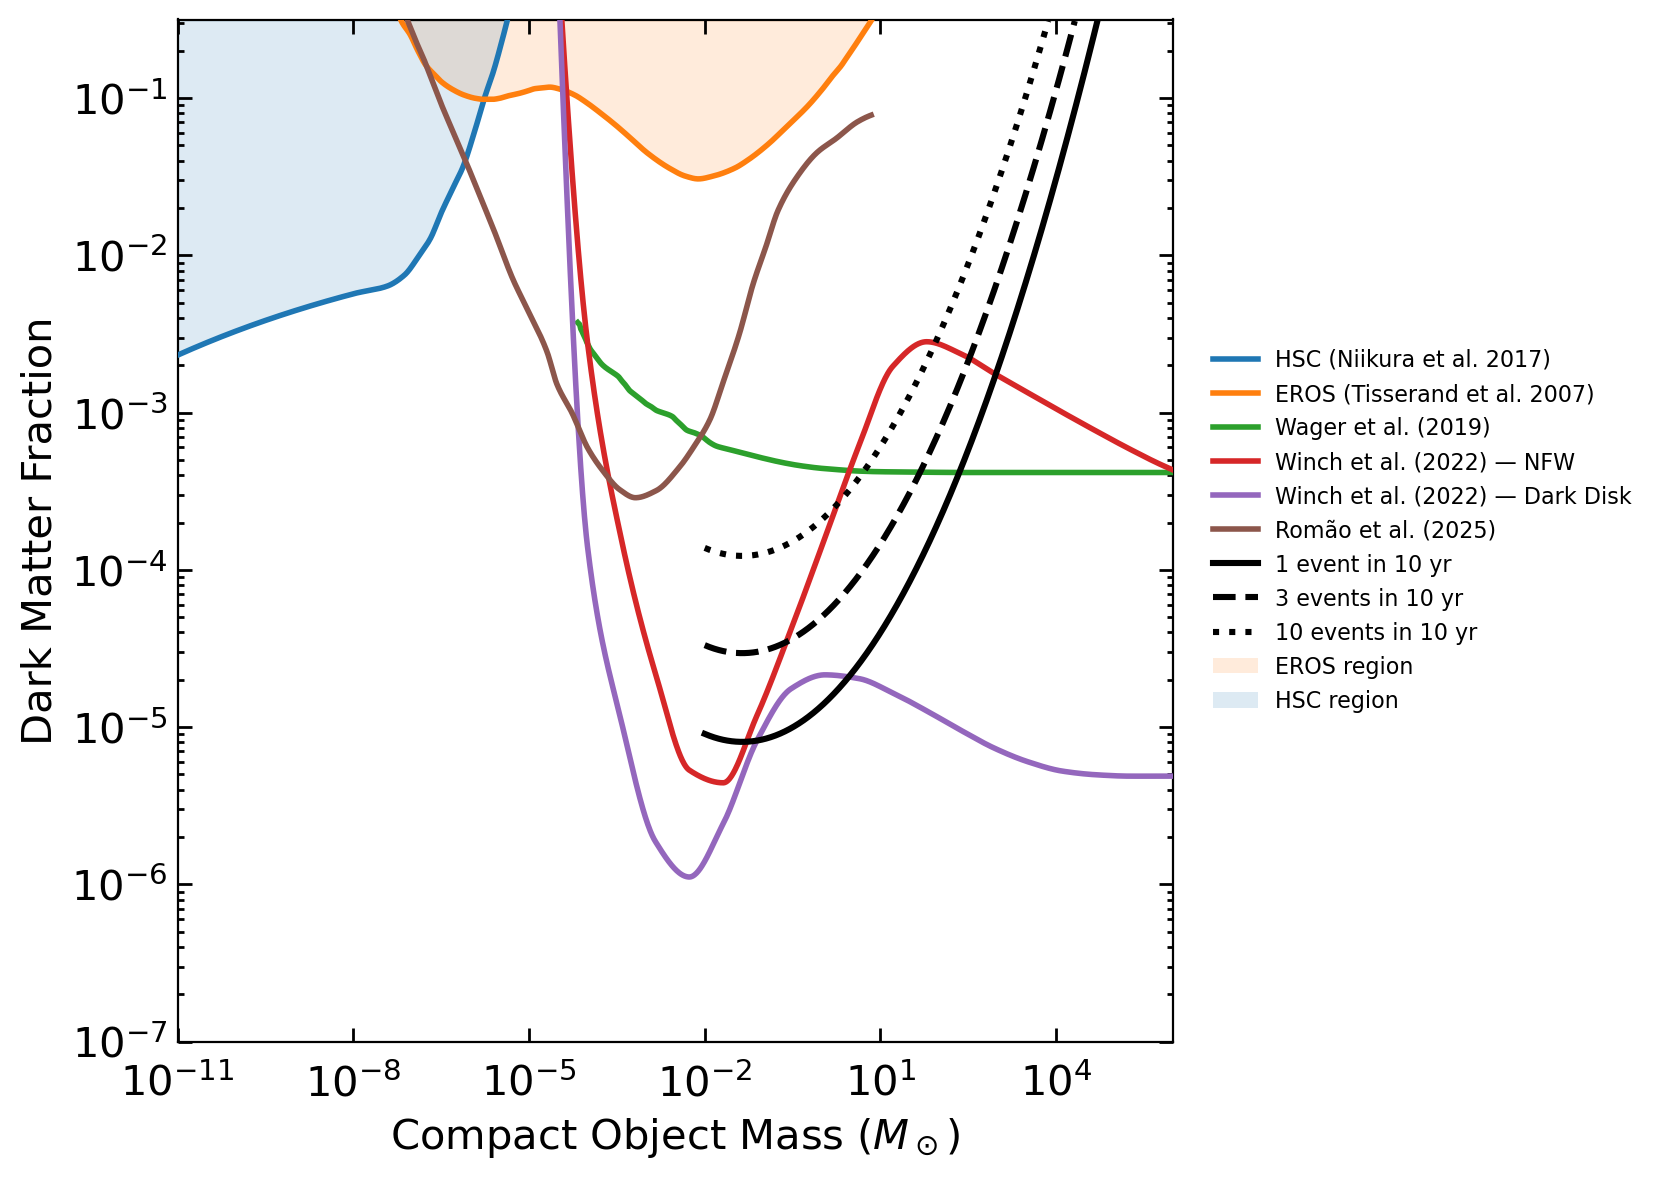

In [100]:
import numpy as np, pandas as pd, os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if "curves" not in globals(): raise RuntimeError("`curves` not found.")
if "d" not in globals():      raise RuntimeError("`d` not found.")

# ---------------- N (per YEAR) from B_combined3.csv ----------------
NPATH = "B_combined3.csv"
if not os.path.exists(NPATH): raise FileNotFoundError(f"{NPATH} not found in {os.getcwd()}.")
nb = pd.read_csv(NPATH); nb.columns = [c.strip() for c in nb.columns]
N_COL = next((c for c in ("N","N_exp","Nevents","n_events","Nev") if c in nb.columns), None)
if N_COL is None: raise KeyError(f"No N column in {NPATH}. Columns = {list(nb.columns)}")

KEYS = ["sigma","omega"]; RND = 6          # <-- round keys to fix float-mismatch merge
for k in KEYS + [N_COL]: nb[k] = pd.to_numeric(nb[k], errors="coerce")
for k in KEYS:           d[k]  = pd.to_numeric(d[k],  errors="coerce")
for k in KEYS:
    nb[k] = nb[k].round(RND); d[k] = d[k].round(RND)
nb_small = (nb[KEYS+[N_COL]].dropna(subset=KEYS)
              .drop_duplicates(KEYS, keep="last").rename(columns={N_COL:"_N"}))
d = d.drop(columns=[c for c in ("_N",) if c in d.columns]).merge(
        nb_small, on=KEYS, how="left", validate="m:1")
print(f"[merge N] col='{N_COL}'  matched {int(d['_N'].notna().sum())}/{len(d)}  (RND={RND})")

# per-1yr -> per-10yr
YEARS = 10.0
d["_N"] = pd.to_numeric(d["_N"], errors="coerce") * YEARS

# ---------------- fit ----------------
FCOL = "fdm_cut_N1"
ok = d[~d.low_pop]
M  = pd.to_numeric(ok["meq_vegas"], errors="coerce").to_numpy(float)
F  = pd.to_numeric(ok[FCOL],         errors="coerce").to_numpy(float)
Nv = pd.to_numeric(ok["_N"],         errors="coerce").to_numpy(float)
m  = np.isfinite(M)&np.isfinite(F)&np.isfinite(Nv)&(M>0)&(F>0)&(Nv>0)
lM, lF, lN = np.log10(M[m]), np.log10(F[m]), np.log10(Nv[m])
X = np.column_stack([np.ones_like(lM), lF, lM, lM**2])
a0,a1,a2,a3 = np.linalg.lstsq(X, lN, rcond=None)[0]
print(f"[fit {FCOL}] n={m.sum()}  a0={a0:.3f} a1={a1:.3f} a2={a2:.3f} a3={a3:.3f}")
def logF_for_N(logM, N_target):
    return (np.log10(N_target) - a0 - a2*logM - a3*logM**2) / a1

# ---------------- plot ----------------
Mmin, Mmax = 1e-11, 1e6
Fmin, Fmax = 1e-7, 10**(-0.5)
M_iso_min  = 1e-2
fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(Mmin, Mmax); ax.set_ylim(Fmin, Fmax)

M_eval = np.logspace(-15, 6, 2000)
line_handles, line_labels = [], []; eros_xy = hsc_xy = None
for f in curves:
    lab = (getattr(f,"label","") or "").strip()
    yy = f(M_eval); mv = np.isfinite(yy)
    if not mv.any(): continue
    edges = np.where(~mv)[0]; start = 0
    for stop in np.append(edges, len(M_eval)):
        if stop - start > 1:
            (ln,) = ax.plot(M_eval[start:stop], yy[start:stop], lw=2.0, zorder=3)
            if lab and lab not in line_labels:
                ln.set_label(lab); line_labels.append(lab); line_handles.append(ln)
        start = stop + 1
    ll = lab.lower()
    if "eros" in ll: eros_xy = (M_eval[mv], yy[mv])
    if "hsc"  in ll: hsc_xy  = (M_eval[mv], yy[mv])

levels = [1,3,10]; linestyles = ['-','--',':']
labels_iso = ["1 event in 10 yr","3 events in 10 yr","10 events in 10 yr"]; iso_handles = []
logM_grid = np.linspace(np.log10(M_iso_min), np.log10(Mmax), 1200)
for L, ls, lab in zip(levels, linestyles, labels_iso):
    Mline = 10**logM_grid; Fline = 10**logF_for_N(logM_grid, L)
    good = np.isfinite(Fline)&(Fline>Fmin)&(Fline<Fmax)&(Mline>=M_iso_min)
    edges = np.where(~good)[0]; start = 0; first = True
    for stop in np.append(edges, len(Mline)):
        if stop - start > 1:
            (h,) = ax.plot(Mline[start:stop], Fline[start:stop],
                           linestyle=ls, color="k", lw=2.2, zorder=4,
                           label=lab if first else None)
            if first: iso_handles.append(h); first = False
        start = stop + 1

shading_handles = []
for xy, color, name in [(eros_xy,"tab:orange","EROS region"), (hsc_xy,"tab:blue","HSC region")]:
    if xy is None: continue
    x, y = xy; w = np.isfinite(y)&(y>Fmin)&(y<Fmax)
    ax.fill_between(x, y, Fmax, where=w, alpha=0.15, color=color, zorder=1)
    shading_handles.append(mpatches.Patch(facecolor=color, alpha=0.15, label=name))

ax.set_xlabel(r"Compact Object Mass ($M_\odot$)")
ax.set_ylabel("Dark Matter Fraction")
ax.legend(handles=line_handles+iso_handles+shading_handles,
          loc="center left", bbox_to_anchor=(1.02,0.5), fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

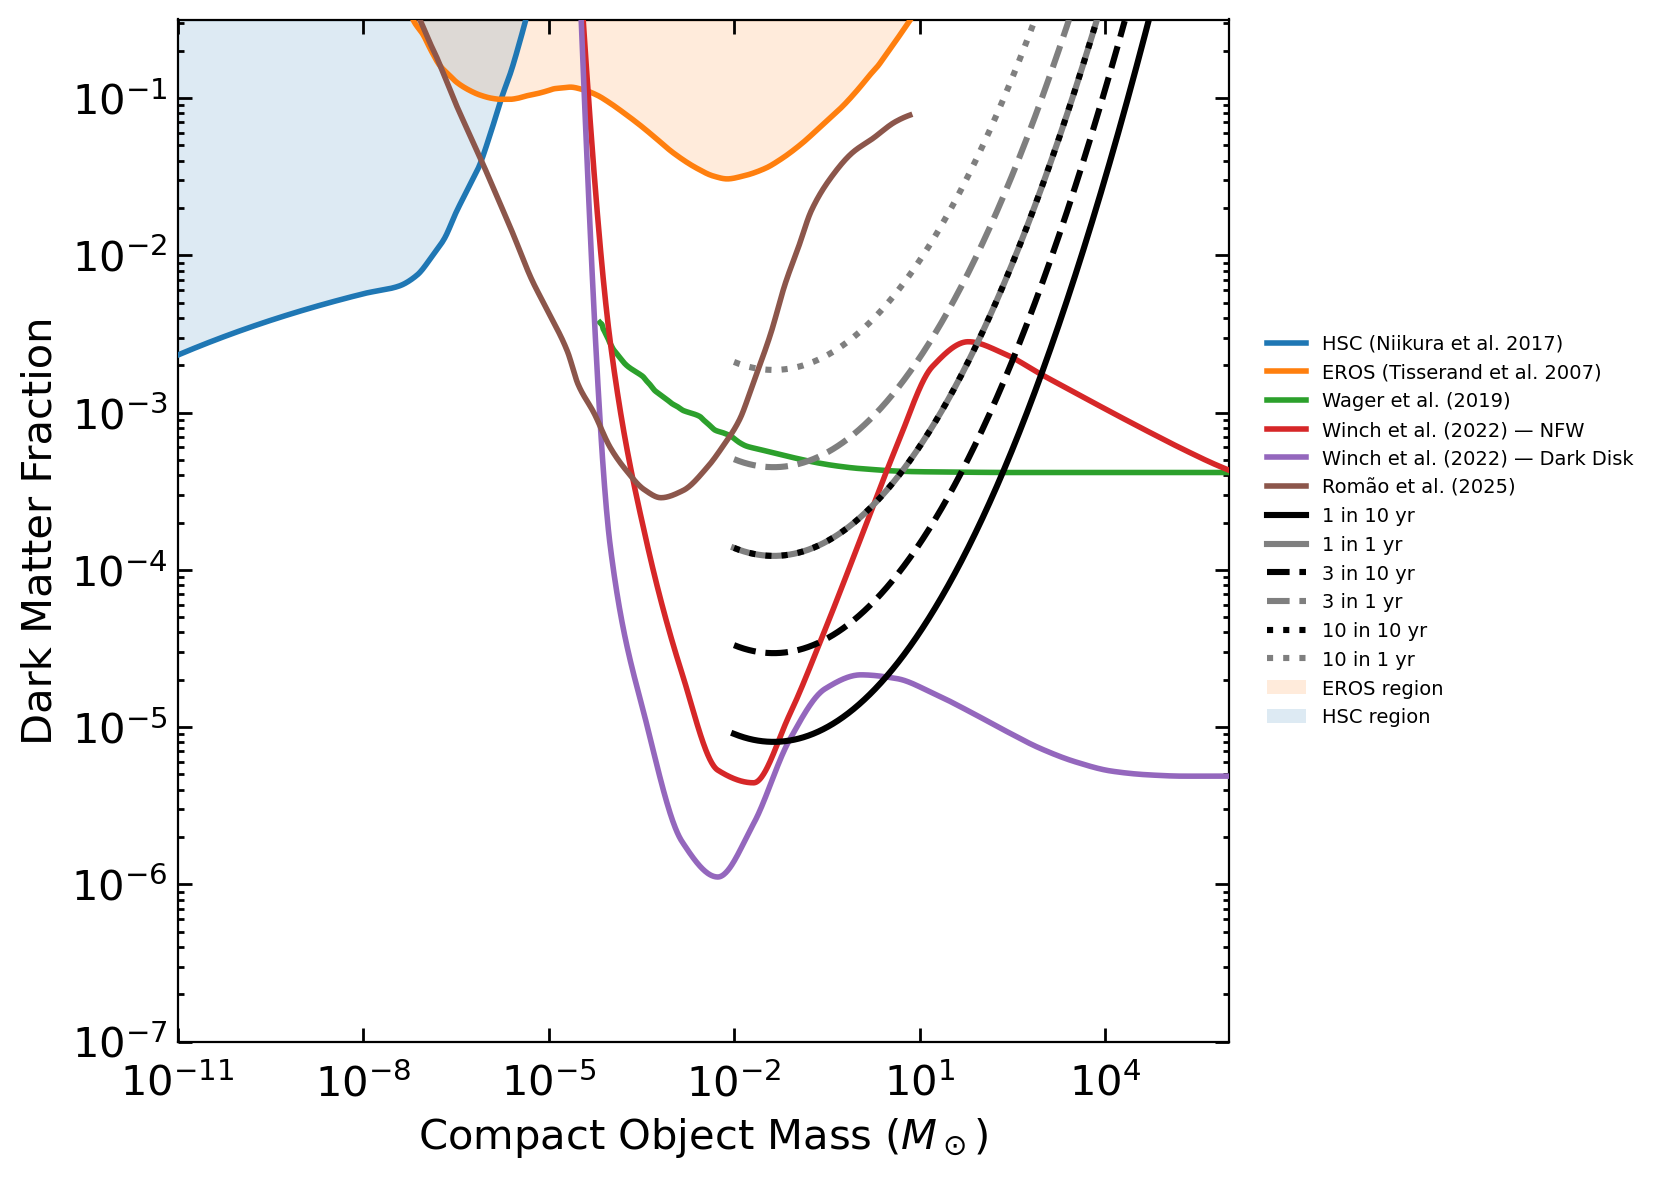

In [ ]:
# ---------------- plot ----------------
Mmin, Mmax = 1e-11, 1e6
Fmin, Fmax = 1e-7, 10**(-0.5)
M_iso_min  = 1e-2
fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(Mmin, Mmax); ax.set_ylim(Fmin, Fmax)

M_eval = np.logspace(-15, 6, 2000)
line_handles, line_labels = [], []; eros_xy = hsc_xy = None
for f in curves:
    lab = (getattr(f,"label","") or "").strip()
    yy = f(M_eval); mv = np.isfinite(yy)
    if not mv.any(): continue
    edges = np.where(~mv)[0]; start = 0
    for stop in np.append(edges, len(M_eval)):
        if stop - start > 1:
            (ln,) = ax.plot(M_eval[start:stop], yy[start:stop], lw=2.0, zorder=3)
            if lab and lab not in line_labels:
                ln.set_label(lab); line_labels.append(lab); line_handles.append(ln)
        start = stop + 1
    ll = lab.lower()
    if "eros" in ll: eros_xy = (M_eval[mv], yy[mv])
    if "hsc"  in ll: hsc_xy  = (M_eval[mv], yy[mv])

# iso-event contours. _N is per-10yr, so:
#   "L in 10 yr"  -> evaluate at L
#   "L in 1 yr"   -> L events/yr = 10*L in 10-yr units -> evaluate at 10*L
levels     = [1, 3, 10]
linestyles = ['-', '--', ':']
logM_grid  = np.linspace(np.log10(M_iso_min), np.log10(Mmax), 1200)
Mline      = 10**logM_grid

def draw_iso(N_target, ls, color, lab):
    Fline = 10**logF_for_N(logM_grid, N_target)
    good  = np.isfinite(Fline)&(Fline>Fmin)&(Fline<Fmax)&(Mline>=M_iso_min)
    edges = np.where(~good)[0]; start=0; first=True; h0=None
    for stop in np.append(edges, len(Mline)):
        if stop-start > 1:
            (h,) = ax.plot(Mline[start:stop], Fline[start:stop],
                           linestyle=ls, color=color, lw=2.2, zorder=4,
                           label=lab if first else None)
            if first: h0=h; first=False
        start = stop+1
    return h0

iso_handles = []
for L, ls in zip(levels, linestyles):
    h10 = draw_iso(L,      ls, "k",       f"{L} in 10 yr")   # 10-year (lower)
    h1  = draw_iso(10*L,   ls, "tab:gray",f"{L} in 1 yr")    # 1-year  (upper, +1.183 dex)
    if h10 is not None: iso_handles.append(h10)
    if h1  is not None: iso_handles.append(h1)

shading_handles = []
for xy, color, name in [(eros_xy,"tab:orange","EROS region"), (hsc_xy,"tab:blue","HSC region")]:
    if xy is None: continue
    x, y = xy; w = np.isfinite(y)&(y>Fmin)&(y<Fmax)
    ax.fill_between(x, y, Fmax, where=w, alpha=0.15, color=color, zorder=1)
    shading_handles.append(mpatches.Patch(facecolor=color, alpha=0.15, label=name))

ax.set_xlabel(r"Compact Object Mass ($M_\odot$)")
ax.set_ylabel("Dark Matter Fraction")
ax.legend(handles=line_handles+iso_handles+shading_handles,
          loc="center left", bbox_to_anchor=(1.02,0.5), fontsize=7, frameon=False)
plt.tight_layout(); plt.show()

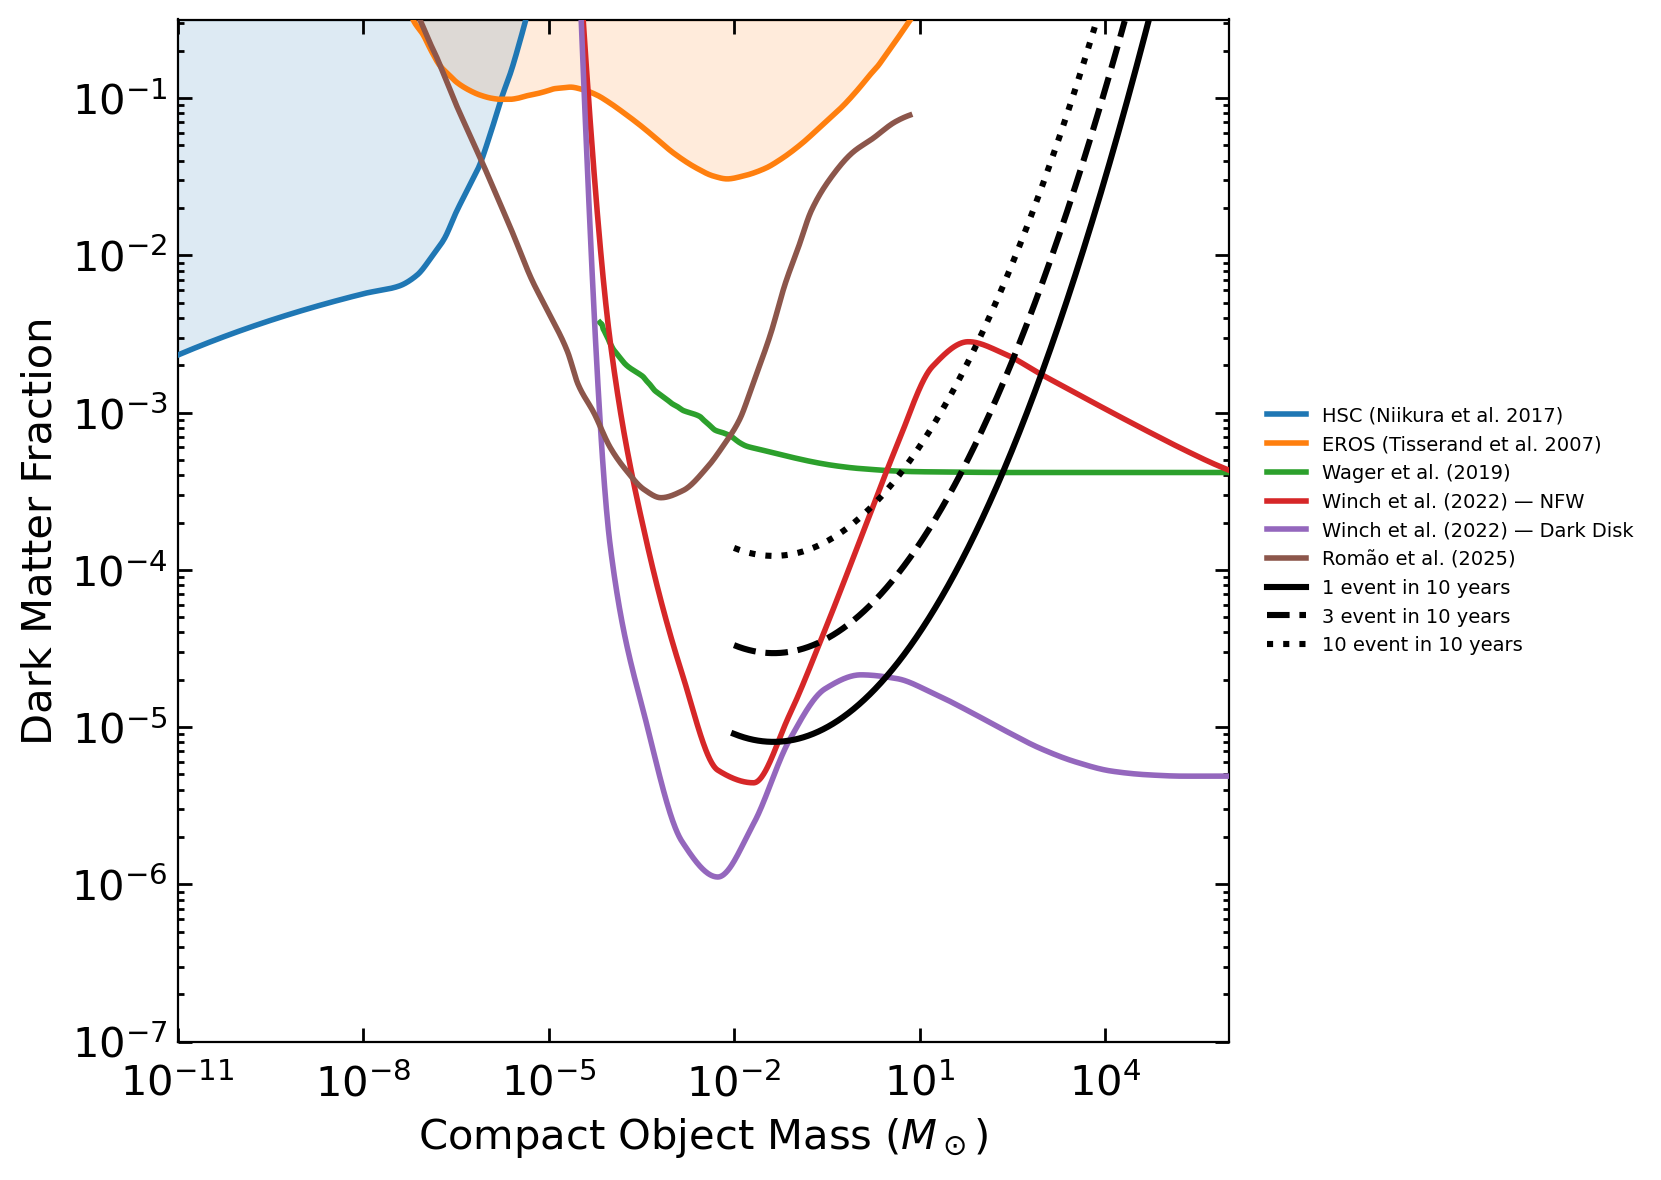

In [124]:
# ---------------- plot ----------------
Mmin, Mmax = 1e-11, 1e6
Fmin, Fmax = 1e-7, 10**(-0.5)
M_iso_min  = 1e-2
fig, ax = plt.subplots(figsize=(8.6, 6.2))
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(Mmin, Mmax); ax.set_ylim(Fmin, Fmax)

M_eval = np.logspace(-15, 6, 2000)
line_handles, line_labels = [], []; eros_xy = hsc_xy = None
for f in curves:
    lab = (getattr(f,"label","") or "").strip()
    yy = f(M_eval); mv = np.isfinite(yy)
    if not mv.any(): continue
    edges = np.where(~mv)[0]; start = 0
    for stop in np.append(edges, len(M_eval)):
        if stop - start > 1:
            (ln,) = ax.plot(M_eval[start:stop], yy[start:stop], lw=2.0, zorder=3)
            if lab and lab not in line_labels:
                ln.set_label(lab); line_labels.append(lab); line_handles.append(ln)
        start = stop + 1
    ll = lab.lower()
    if "eros" in ll: eros_xy = (M_eval[mv], yy[mv])
    if "hsc"  in ll: hsc_xy  = (M_eval[mv], yy[mv])

# iso-event contours. _N is per-10yr, so:
#   "L in 10 yr"  -> evaluate at L
#   "L in 1 yr"   -> L events/yr = 10*L in 10-yr units -> evaluate at 10*L
levels     = [1, 3, 10]
linestyles = ['-', '--', ':']
logM_grid  = np.linspace(np.log10(M_iso_min), np.log10(Mmax), 1200)
Mline      = 10**logM_grid

def draw_iso(N_target, ls, color, lab):
    Fline = 10**logF_for_N(logM_grid, N_target)
    good  = np.isfinite(Fline)&(Fline>Fmin)&(Fline<Fmax)&(Mline>=M_iso_min)
    edges = np.where(~good)[0]; start=0; first=True; h0=None
    for stop in np.append(edges, len(Mline)):
        if stop-start > 1:
            (h,) = ax.plot(Mline[start:stop], Fline[start:stop],
                           linestyle=ls, color=color, lw=2.2, zorder=4,
                           label=lab if first else None)
            if first: h0=h; first=False
        start = stop+1
    return h0

iso_handles = []
for L, ls in zip(levels, linestyles):
    h10 = draw_iso(L,      ls, "k",       f"{L} event in 10 years")   # 10-year (lower)
    #h1  = draw_iso(10*L,   ls, "tab:gray",f"{L} in 1 yr")    # 1-year  (upper, +1.183 dex)
    if h10 is not None: iso_handles.append(h10)
    if h1  is not None: iso_handles.append(h1)

shading_handles = []
for xy, color, name in [(eros_xy,"tab:orange","EROS region"), (hsc_xy,"tab:blue","HSC region")]:
    if xy is None: continue
    x, y = xy; w = np.isfinite(y)&(y>Fmin)&(y<Fmax)
    ax.fill_between(x, y, Fmax, where=w, alpha=0.15, color=color, zorder=1)
    shading_handles.append(mpatches.Patch(facecolor=color, alpha=0.15, label=name))


keep = [(h, l) for h, l in zip(iso_handles, [h.get_label() for h in iso_handles])
        if "10 yr" in l]
iso_keep = [h for h, l in keep]
iso_keep = [h for h in iso_handles if "event in 10 years" in h.get_label()]

ax.legend(handles=line_handles + iso_keep,
          loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=7, frameon=False)

ax.set_xlabel(r"Compact Object Mass ($M_\odot$)")
ax.set_ylabel("Dark Matter Fraction")

plt.tight_layout(); plt.show()

In [101]:
import numpy as np, pandas as pd
from numpy.polynomial import polynomial as P

# ---- pull the fit sample exactly as the plot does ----
FCOL = "fdm_cut_N1"
ok = d[~d.low_pop]
M  = pd.to_numeric(ok["meq_vegas"], errors="coerce").to_numpy(float)
F  = pd.to_numeric(ok[FCOL],         errors="coerce").to_numpy(float)
Nyr= pd.to_numeric(ok["_N"],         errors="coerce").to_numpy(float)   # NOTE: per-year if you removed the *10
m  = np.isfinite(M)&np.isfinite(F)&np.isfinite(Nyr)&(M>0)&(F>0)&(Nyr>0)
lM,lF,lN = np.log10(M[m]), np.log10(F[m]), np.log10(Nyr[m])

# ===== TEST 1: is N linear in f?  (a1 should be 1.0) =====
X = np.column_stack([np.ones_like(lM), lF, lM, lM**2])
beta, res, *_ = np.linalg.lstsq(X, lN, rcond=None)
# bootstrap CI on a1
rng = np.random.default_rng(0); B=2000; a1s=np.empty(B)
for b in range(B):
    i = rng.integers(0, len(lN), len(lN))
    bb,*_ = np.linalg.lstsq(X[i], lN[i], rcond=None); a1s[b]=bb[1]
lo,hi = np.percentile(a1s,[2.5,97.5])
print(f"TEST1  a1={beta[1]:.3f}  95% CI=[{lo:.3f},{hi:.3f}]  "
      f"consistent with 1? {'YES' if lo<=1<=hi else 'NO'}")

# ===== TEST 2: direct check of N ∝ f at fixed M (bin in M, regress lnN on lnf) =====
# if events truly scale linearly with f, slope ~1 inside each narrow mass bin
edges = np.percentile(lM, np.linspace(0,100,8))
print("TEST2  per-M-bin slope of logN vs logf (expect ~1):")
for i in range(len(edges)-1):
    sel = (lM>=edges[i])&(lM<edges[i+1])
    if sel.sum() < 20: continue
    s = np.polyfit(lF[sel], lN[sel], 1)[0]
    print(f"  M in [1e{edges[i]:.1f},1e{edges[i+1]:.1f}]  n={sel.sum():4d}  slope={s:+.2f}")

# ===== TEST 3: the shift is exactly -1/a1 dex, mass-independent. verify numerically =====
a0,a1,a2,a3 = beta
def logf(logM, Ntarget): return (np.log10(Ntarget)-a0-a2*logM-a3*logM**2)/a1
gM = np.linspace(lM.min(), lM.max(), 50)
shift = logf(gM, 0.1) - logf(gM, 1.0)      # 1-in-10yr (=0.1/yr) minus 1-in-1yr (=1/yr)
print(f"TEST3  Δlog10 f from 1yr->10yr labelling: mean={shift.mean():+.3f} dex, "
      f"spread={shift.std():.2e} (should be flat = -1/a1 = {-1/a1:+.3f})")

TEST1  a1=0.846  95% CI=[0.829,0.859]  consistent with 1? NO
TEST2  per-M-bin slope of logN vs logf (expect ~1):
  M in [1e-3.7,1e-1.0]  n= 227  slope=+0.94
  M in [1e-1.0,1e0.5]  n= 226  slope=+0.85
  M in [1e0.5,1e1.5]  n= 227  slope=+0.84
  M in [1e1.5,1e2.3]  n= 226  slope=+0.84
  M in [1e2.3,1e3.1]  n= 227  slope=+0.84
  M in [1e3.1,1e4.5]  n= 226  slope=+0.87
  M in [1e4.5,1e5.5]  n= 226  slope=+0.85
TEST3  Δlog10 f from 1yr->10yr labelling: mean=-1.183 dex, spread=4.34e-16 (should be flat = -1/a1 = -1.183)


In [102]:
import numpy as np, pandas as pd
def slope_report(frame, FCOL, tag):
    ok = frame[~frame.low_pop]
    M  = pd.to_numeric(ok["meq_vegas"], errors="coerce").to_numpy(float)
    F  = pd.to_numeric(ok[FCOL],        errors="coerce").to_numpy(float)
    Nv = pd.to_numeric(ok["_N"],        errors="coerce").to_numpy(float)
    m  = np.isfinite(M)&np.isfinite(F)&np.isfinite(Nv)&(M>0)&(F>0)&(Nv>0)
    lM,lF,lN = np.log10(M[m]), np.log10(F[m]), np.log10(Nv[m])
    X = np.column_stack([np.ones_like(lM), lF, lM, lM**2])
    b,*_ = np.linalg.lstsq(X, lN, rcond=None)
    rng = np.random.default_rng(0); a1s=np.empty(1500)
    for k in range(1500):
        i=rng.integers(0,len(lN),len(lN)); bb,*_=np.linalg.lstsq(X[i],lN[i],rcond=None); a1s[k]=bb[1]
    lo,hi=np.percentile(a1s,[2.5,97.5])
    print(f"{tag:14s} n={m.sum():4d}  a1={b[1]:.3f}  CI=[{lo:.3f},{hi:.3f}]  ~1? {'YES' if lo<=1<=hi else 'NO'}")

slope_report(d, "fdm_cut_N1", "cut_N1")
slope_report(d, "fdm_s1",     "s1_window")

cut_N1         n=1586  a1=0.846  CI=[0.830,0.860]  ~1? NO
s1_window      n=1586  a1=0.987  CI=[0.981,0.992]  ~1? NO


[load] fdm_final_4.csv col='fdm_cut_N1'  rows=5542  finite&pos f=5542


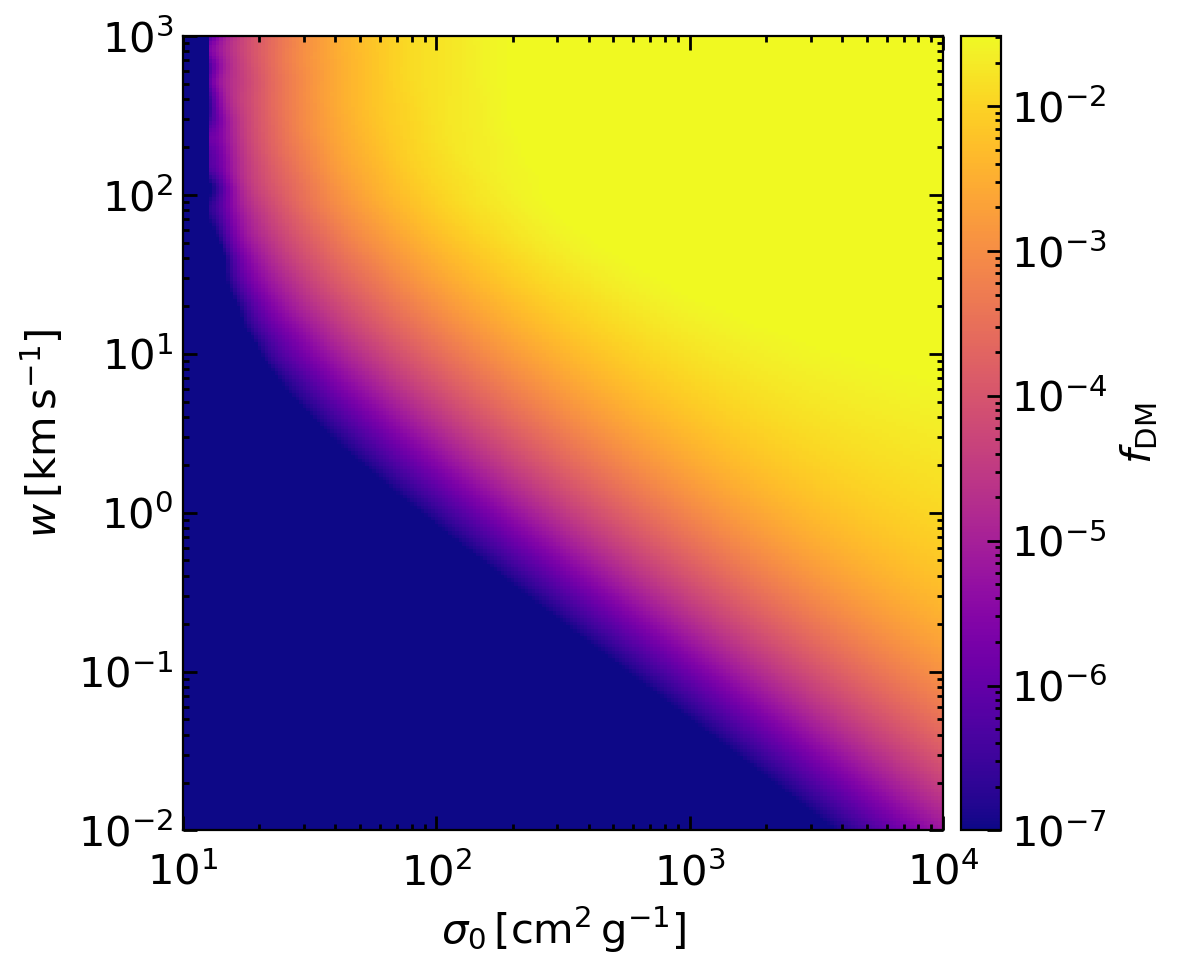

In [113]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator

# ---- load S, W, F from fdm_final_4.csv (fdm_cut_N1) ----
FDM_PATH = "fdm_final_4.csv"
FCOL     = "fdm_cut_N1"
if not os.path.exists(FDM_PATH):
    raise FileNotFoundError(f"{FDM_PATH} not found in {os.getcwd()}.")
fd = pd.read_csv(FDM_PATH); fd.columns = [c.strip() for c in fd.columns]
if FCOL not in fd.columns:
    raise KeyError(f"'{FCOL}' not in {FDM_PATH}. Columns = {list(fd.columns)}")
for c in ("sigma", "omega", FCOL):
    fd[c] = pd.to_numeric(fd[c], errors="coerce")
S = fd["sigma"].to_numpy(float)
W = fd["omega"].to_numpy(float)
F = fd[FCOL].to_numpy(float)
print(f"[load] {FDM_PATH} col='{FCOL}'  rows={len(fd)}  "
      f"finite&pos f={int((np.isfinite(F)&(F>0)).sum())}")

# --- config (identical to cell 13) ---
fdm_clim = (1e-7, 0.0306)
xlim     = (1e1, 1e4)
ylim     = (1e-2, 1e3)
ngrid    = 220
smooth   = 0.25
cmap     = "plasma"

# --- mask finite/positive ---
m = np.isfinite(S) & np.isfinite(W) & np.isfinite(F) & (S > 0) & (W > 0) & (F > 0)
S_, W_, F_ = S[m], W[m], F[m]

# --- build grid in log-space ---
xg = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), ngrid)
yg = np.logspace(np.log10(ylim[0]), np.log10(ylim[1]), ngrid)
Xg, Yg = np.meshgrid(xg, yg, indexing="xy")

XY     = np.column_stack([np.log10(S_), np.log10(W_)])
XYgrid = np.column_stack([np.log10(Xg).ravel(), np.log10(Yg).ravel()])
Z      = np.log10(F_)

def _evaluate_log_rbf(XY, Z, XYgrid, smooth=0.25):
    try:
        from scipy.interpolate import RBFInterpolator
        rbf = RBFInterpolator(XY, Z, smoothing=smooth, kernel="multiquadric")
        return rbf(XYgrid)
    except Exception:
        try:
            from scipy.interpolate import Rbf
            rbf = Rbf(XY[:,0], XY[:,1], Z, function="multiquadric", smooth=smooth)
            return rbf(XYgrid[:,0], XYgrid[:,1])
        except Exception:
            out = np.empty(len(XYgrid))
            for i, q in enumerate(XYgrid):
                d = np.maximum(np.hypot(XY[:,0]-q[0], XY[:,1]-q[1]), 1e-9)
                w = 1.0/(d**2); out[i] = np.sum(w*Z)/np.sum(w)
            return out

Zg = _evaluate_log_rbf(XY, Z, XYgrid, smooth=smooth)
Fg = np.clip(10**Zg, fdm_clim[0], fdm_clim[1]).reshape(Xg.shape)

# floor the unsampled/edge-artifact region (cosmetic)
FLOOR = fdm_clim[0]
edge = (np.log10(Xg) < 1.1)            # everything below σ₀ = 10^1.3 ≈ 20
Fg = np.where(edge, FLOOR, Fg)

# --- plot (identical to cell 13) ---
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(*xlim);   ax.set_ylim(*ylim)
ax.grid(False)
pcm = ax.pcolormesh(Xg, Yg, Fg, shading="auto", cmap=cmap, norm=LogNorm(*fdm_clim))
ax.set_xlabel(r'$\sigma_0\,[\mathrm{cm^2\,g^{-1}}]$')
ax.set_ylabel(r'$w\,[\mathrm{km\,s^{-1}}]$')
ax.xaxis.set_ticks_position("both"); ax.yaxis.set_ticks_position("both")
ax.tick_params(axis="x", which="both", bottom=True, top=True,
               labelbottom=True, labeltop=False, direction="in")
ax.tick_params(axis="y", which="both", left=True, right=True,
               labelleft=True, labelright=False, direction="in")
cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label(r"$f_{\rm DM}$")
cbar.locator = LogLocator(base=10); cbar.update_ticks()
plt.tight_layout(); plt.show()
# at least one subhalo 

[load] fdm_final_4.csv col='fdm_cut_N3'  rows=5542  finite&pos f=5542


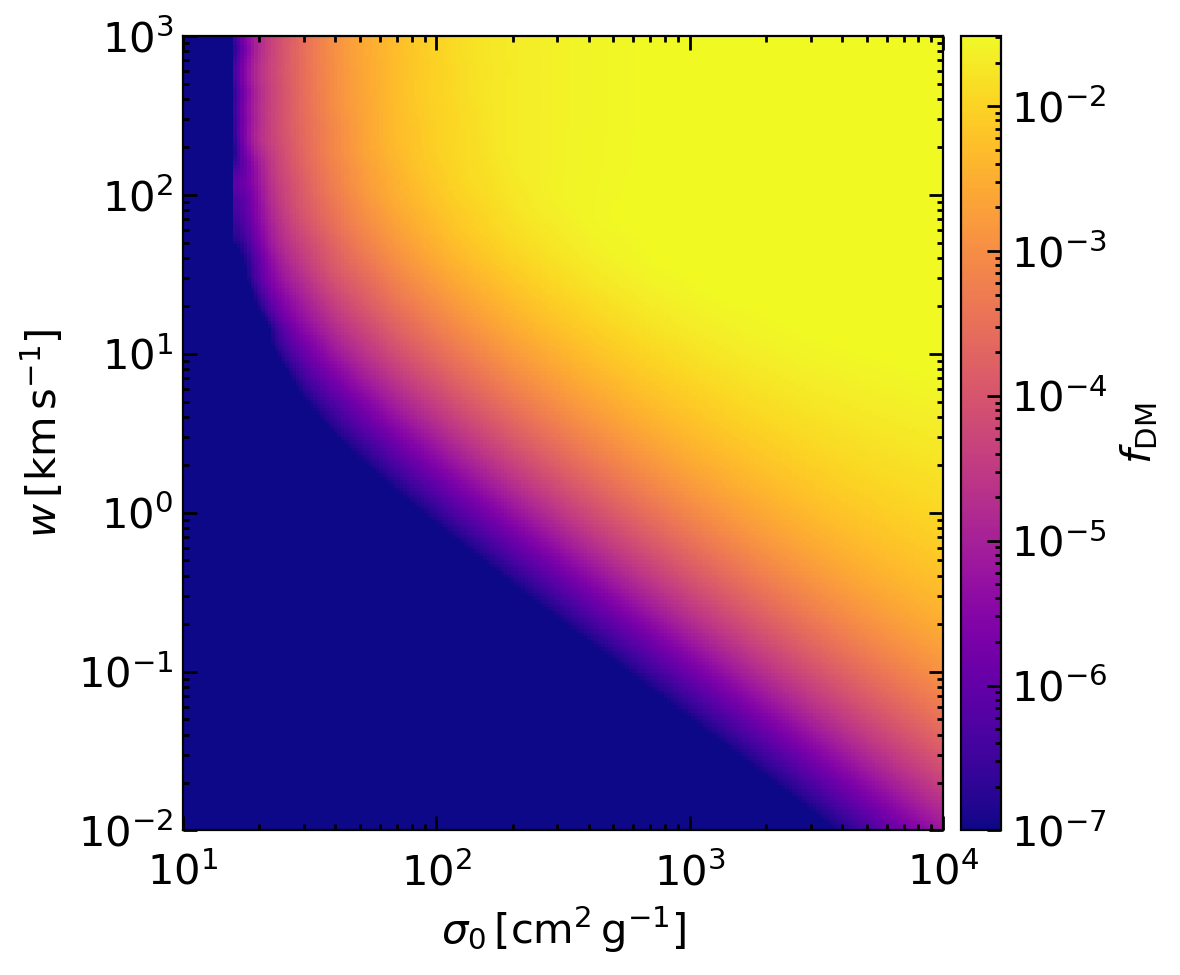

In [115]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator

# ---- load S, W, F from fdm_final_4.csv (fdm_cut_N1) ----
FDM_PATH = "fdm_final_4.csv"
FCOL     = "fdm_cut_N3"
if not os.path.exists(FDM_PATH):
    raise FileNotFoundError(f"{FDM_PATH} not found in {os.getcwd()}.")
fd = pd.read_csv(FDM_PATH); fd.columns = [c.strip() for c in fd.columns]
if FCOL not in fd.columns:
    raise KeyError(f"'{FCOL}' not in {FDM_PATH}. Columns = {list(fd.columns)}")
for c in ("sigma", "omega", FCOL):
    fd[c] = pd.to_numeric(fd[c], errors="coerce")
S = fd["sigma"].to_numpy(float)
W = fd["omega"].to_numpy(float)
F = fd[FCOL].to_numpy(float)
print(f"[load] {FDM_PATH} col='{FCOL}'  rows={len(fd)}  "
      f"finite&pos f={int((np.isfinite(F)&(F>0)).sum())}")

# --- config (identical to cell 13) ---
fdm_clim = (1e-7, 0.0306)
xlim     = (1e1, 1e4)
ylim     = (1e-2, 1e3)
ngrid    = 220
smooth   = 0.25
cmap     = "plasma"

# --- mask finite/positive ---
m = np.isfinite(S) & np.isfinite(W) & np.isfinite(F) & (S > 0) & (W > 0) & (F > 0)
S_, W_, F_ = S[m], W[m], F[m]

# --- build grid in log-space ---
xg = np.logspace(np.log10(xlim[0]), np.log10(xlim[1]), ngrid)
yg = np.logspace(np.log10(ylim[0]), np.log10(ylim[1]), ngrid)
Xg, Yg = np.meshgrid(xg, yg, indexing="xy")

XY     = np.column_stack([np.log10(S_), np.log10(W_)])
XYgrid = np.column_stack([np.log10(Xg).ravel(), np.log10(Yg).ravel()])
Z      = np.log10(F_)

def _evaluate_log_rbf(XY, Z, XYgrid, smooth=0.25):
    try:
        from scipy.interpolate import RBFInterpolator
        rbf = RBFInterpolator(XY, Z, smoothing=smooth, kernel="multiquadric")
        return rbf(XYgrid)
    except Exception:
        try:
            from scipy.interpolate import Rbf
            rbf = Rbf(XY[:,0], XY[:,1], Z, function="multiquadric", smooth=smooth)
            return rbf(XYgrid[:,0], XYgrid[:,1])
        except Exception:
            out = np.empty(len(XYgrid))
            for i, q in enumerate(XYgrid):
                d = np.maximum(np.hypot(XY[:,0]-q[0], XY[:,1]-q[1]), 1e-9)
                w = 1.0/(d**2); out[i] = np.sum(w*Z)/np.sum(w)
            return out

Zg = _evaluate_log_rbf(XY, Z, XYgrid, smooth=smooth)
Fg = np.clip(10**Zg, fdm_clim[0], fdm_clim[1]).reshape(Xg.shape)

# floor the unsampled/edge-artifact region (cosmetic)
FLOOR = fdm_clim[0]
edge = (np.log10(Xg) < 1.2)            # everything below σ₀ = 10^1.3 ≈ 20
Fg = np.where(edge, FLOOR, Fg)

# --- plot (identical to cell 13) ---
fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlim(*xlim);   ax.set_ylim(*ylim)
ax.grid(False)
pcm = ax.pcolormesh(Xg, Yg, Fg, shading="auto", cmap=cmap, norm=LogNorm(*fdm_clim))
ax.set_xlabel(r'$\sigma_0\,[\mathrm{cm^2\,g^{-1}}]$')
ax.set_ylabel(r'$w\,[\mathrm{km\,s^{-1}}]$')
ax.xaxis.set_ticks_position("both"); ax.yaxis.set_ticks_position("both")
ax.tick_params(axis="x", which="both", bottom=True, top=True,
               labelbottom=True, labeltop=False, direction="in")
ax.tick_params(axis="y", which="both", left=True, right=True,
               labelleft=True, labelright=False, direction="in")
cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
cbar.set_label(r"$f_{\rm DM}$")
cbar.locator = LogLocator(base=10); cbar.update_ticks()
plt.tight_layout(); plt.show()
# at least one subhalo 

In [110]:
print(f"sigma data min = {S_.min():.4g}, log10 = {np.log10(S_.min()):.3f}")

sigma data min = 0.1, log10 = -1.000


abundance ceiling M_abund = the highest subhalo mass where the collapsed cumulative count N(>M) ≥ Nthr (1 or 3). So "at least Nthr collapsed subhalos above that mass."
mass-ratio ceiling mratio_cap = 1.5×10¹⁰ M⊙ (1% of M_host). 

In [ ]:
print(f"sigma data min = {S_.min():.4g}, log10 = {np.log10(S_.min()):.3f}")

sigma data min = 0.1, log10 = -1.000
